Imports

In [1]:
# imports
from esdl import esdl
from esdl.esdl_handler import EnergySystemHandler
import pandas as pd
import numpy as np
import numpy_financial as npf
from decimal import Decimal, ROUND_HALF_UP
import matplotlib.pyplot as plt

In [2]:
# This imports all input variables from OWF_input_data.py
from EL_input_data import *

# import all data from ESDL
from NSE_get_data_from_ESDL import *

# Make sure to select the scenario (e.g., pessimistic, most likely, optimistic) in the NSE_get_data_from_ESDL file
# Check the scenario that is selected 

print(f'Current scenario = {current_scenario}')

XMLResource loading...
All variables saved to NSE_get_data_from_ESDL.pkl
Current scenario = ['most_likely']


In [3]:
asset_parameters

name,power,efficiency,investment_costs,fixed_opex,variable_opex,wacc
TNVDW,700000000.0,,1750.0,2.25,5.0,8.5
Electrolyzer,500.0,0.6,2000.0,2.0,0.0,8.25
Offtaker,24900000.0,,0.0,0.0,0.0,10.5


Set up calendar_year, business_case_year, operations_years, and decommissioning_years lists

In [4]:
# to do sensitivity analysis on lifetime_investment we need to be able to recalculate calendar_year_list, operation_years_list etc. 

def construct_calendar_year_list(lifetime_investment_variable):
    
    year_construction_start = tender_year + 1
    year_start_operation = year_construction_start + duration_construction
    year_decommissioning_start = (year_start_operation + int(Decimal(lifetime_investment_variable).to_integral_value(rounding=ROUND_HALF_UP)))
    # use Decimal.to_integral_value to prevent python to round to nearest even integral
    # this method uses the same rounding method as Excel (i.e., x.5 is rounded up)

    calendar_year_list = list(range(tender_year, year_decommissioning_start + duration_decommissioning))  

    return calendar_year_list

def construct_business_case_year_list(lifetime_investment_variable):

    business_case_year_list = np.array(range(len(construct_calendar_year_list(lifetime_investment_variable))))
    
    return business_case_year_list

def construct_operations_years_list(lifetime_investment_variable):

    year_construction_start = tender_year + 1
    year_start_operation = year_construction_start + duration_construction

    operations_years_list = list(range(year_start_operation, year_start_operation + int(Decimal(lifetime_investment_variable).to_integral_value(rounding=ROUND_HALF_UP))))
    
    return operations_years_list

def construct_decomissioning_years_list(lifetime_investment_variable):

    year_construction_start = tender_year + 1
    year_start_operation = year_construction_start + duration_construction
    year_decommissioning_start = year_start_operation + int(Decimal(lifetime_investment_variable).to_integral_value(rounding=ROUND_HALF_UP))

    decomissioning_years_list = list(range(year_decommissioning_start, year_decommissioning_start + duration_decommissioning))

    return decomissioning_years_list

Start business case analysis

Construction phase

In [5]:
def construction_phase(capex_variable,lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows in the construction phase'''

    # set up df
    df_construction_phase = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_construction_phase.columns.name = "construction_phase"
    
    #### function to calculate CAPEX
    def calculate_capex(capex_variable):
        ''' This function calculates the yearly capex for each of the construction years'''
        capex_list = []
    
        for x in construct_calendar_year_list(lifetime_investment_variable): 
            if x in construction_years_list:
                capex_list.append(-capex_variable/duration_construction)
            else: 
                capex_list.append(0)

        return capex_list
    
    # add CAPEX to df
    df_construction_phase.loc['capex'] = calculate_capex(capex_variable)

    # calculate total cashflow from investments then add to df
    # at this moment only one cashflow is in construction phase, can be expanded later
    total_cashflow_investment = calculate_capex(capex_variable)
    df_construction_phase.loc['total_cashflow_investment'] = total_cashflow_investment
    
    return df_construction_phase

In [6]:
construction_phase(el_capex_100mw,el_lifetime).style.format(precision=2)

construction_phase,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
capex,0.00,-696.33,-696.33,-696.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
total_cashflow_investment,0.00,-696.33,-696.33,-696.33,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00


Operational phase

In [7]:
def operational_phase(df_opex_variable,
                      inflation_variable,
                      annual_electricity_costs_ppa_variable,
                      annual_electricity_costs_grid_variable,
                      electricity_grid_connection_variable,
                      h2_storage_costs_variable,
                      df_stack_replacement_costs_variable,
                      hydrogen_revenues_variable,
                      hwi_revenues_variable,
                      lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows in the operational phase'''
    
    #construct df
    df_operational_phase = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_operational_phase.columns.name = "operational_phase"
    
    #### function
    def calculate_opex(df_opex_variable,variable_name):
        '''This function calculates the opex for all the operational years'''

        opex_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                opex_list.append(-df_opex_variable.loc[variable_name,x]*((1 + inflation_variable)**i))

            else:
                opex_list.append(0)

        return opex_list
    
    # add opex to df
    df_operational_phase.loc['opex'] = calculate_opex(df_opex_variable, 'opex')
    df_operational_phase.loc['purchase_electricity_ppa'] = calculate_opex(annual_electricity_costs_ppa_variable, 'el_annual_electricity_costs_ppa')
    df_operational_phase.loc['purchase_electricity_grid'] = calculate_opex(annual_electricity_costs_grid_variable, 'el_annual_electricity_costs_grid')    


    #### function
    def electricity_grid_connection(electricity_grid_connection_variable):
        '''This function calculates the costs to connect to the electricity grid'''

        electricity_grid_connection_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                electricity_grid_connection_list.append(-electricity_grid_connection_variable*((1 + inflation_variable)**i))

            else:
                electricity_grid_connection_list.append(0)

        return electricity_grid_connection_list

    # add electricity grid connection costs to df
    df_operational_phase.loc['electricity_grid_connection'] = electricity_grid_connection(electricity_grid_connection_variable)


    # add storage costs to df
    df_operational_phase.loc['h2_storage_costs'] = calculate_opex(h2_storage_costs_variable, 'el_h2_storage_costs')
    
    
    #### function
    def stack_replacement(df_stack_replacement_costs_variable):
        '''This function calculated the stack replacement costs'''

        stack_replacement_list = []
        

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable) and (x - construction_years_list[-1]) % 5 == 0:

                stack_replacement_list.append(-df_stack_replacement_costs_variable.loc['stack_replacement',x]*((1 + inflation_variable)**i))

            else:
                stack_replacement_list.append(0)

        return stack_replacement_list

    # add stack replacement to df
    df_operational_phase.loc['stack_replacement'] = stack_replacement(df_stack_replacement_costs_variable)


    # calculate total outflow opex and add to df
    total_outflow_opex = (np.array(calculate_opex(df_opex_variable, 'opex')) + 
                          np.array(calculate_opex(annual_electricity_costs_ppa_variable, 'el_annual_electricity_costs_ppa')) +
                          np.array(calculate_opex(annual_electricity_costs_grid_variable, 'el_annual_electricity_costs_grid')) +
                          np.array(electricity_grid_connection(electricity_grid_connection_variable)) +
                          np.array(calculate_opex(h2_storage_costs_variable, 'el_h2_storage_costs')) + 
                          np.array(stack_replacement(df_stack_replacement_costs_variable)))
       
    df_operational_phase.loc['total_outflow_opex'] = total_outflow_opex


    #### function
    def hydrogen_revenues(hydrogen_revenues_variable, variable_name):
        '''This function calculates the annual hydrogen revenues from the HPA'''

        hydrogen_revenues_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_operations_years_list(lifetime_investment_variable):
                hydrogen_revenues_list.append(hydrogen_revenues_variable.loc[variable_name,x]*((1 + inflation_variable)**i))
            else: 
                hydrogen_revenues_list.append(0)

        return hydrogen_revenues_list
    
    # add revenues costs to df
    df_operational_phase.loc['h2_revenues'] = hydrogen_revenues(hydrogen_revenues_variable, 'el_h2_revenues')
    df_operational_phase.loc['hwi_revenues'] = hydrogen_revenues(hwi_revenues_variable, 'el_hwi_revenues')        
    # df_operational_phase.loc['hwi_revenues'] = np.array(df_operational_phase.loc['hwi_revenues'] * 0)             # can be used to see what happens if HWI = 0, but in base case should not be used

    #calculate total revenues and add to df 
    total_revenues_opex = np.array(hydrogen_revenues(hydrogen_revenues_variable, 'el_h2_revenues')) + np.array(hydrogen_revenues(hwi_revenues_variable, 'el_hwi_revenues')) 
    df_operational_phase.loc['total_revenues_opex'] = total_revenues_opex

    # calculate net cashflow from operation (=EBITDA) and add to df
    net_cashflow_operation = total_outflow_opex + total_revenues_opex
    df_operational_phase.loc['net_cashflow_operations'] = net_cashflow_operation
    
    return df_operational_phase

In [8]:
operational_phase(df_el_opex_100mw,
                  el_inflation,
                  el_annual_electricity_costs_ppa,
                  el_annual_electricity_costs_grid,
                  el_electricity_grid_connection,
                  el_h2_storage_costs,
                  df_stack_replacement_100mw,
                  el_h2_revenues,
                  el_hwi_revenues,
                  el_lifetime).style.format(precision=2)

operational_phase,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
opex,0.00,0.00,0.00,0.00,-164.10,-163.07,-161.94,-160.70,-159.35,-157.87,-156.28,-154.55,-152.70,-150.71,-153.72,-156.79,-159.93,-163.13,-166.39,-169.72,-173.11,-176.58,-180.11,-183.71,-187.38,-191.13,-194.95,-198.85,-202.83,0.00,0.00
purchase_electricity_ppa,0.00,0.00,0.00,0.00,-103.42,-105.44,-107.49,-109.59,-111.73,-113.91,-116.13,-118.39,-120.70,-123.05,-117.26,-111.18,-104.81,-98.14,-91.17,-83.87,-76.25,-68.29,-59.98,-51.31,-52.33,-53.38,-54.45,-55.54,-56.65,0.00,0.00
purchase_electricity_grid,0.00,0.00,0.00,0.00,-10.20,-12.18,-14.24,-16.38,-18.59,-20.89,-23.27,-25.74,-28.30,-30.96,-28.56,-26.06,-23.44,-20.71,-17.86,-14.89,-11.80,-8.57,-5.21,-1.71,-1.75,-1.78,-1.82,-1.86,-1.89,0.00,0.00
electricity_grid_connection,0.00,0.00,0.00,0.00,-31.24,-31.86,-32.50,-33.15,-33.81,-34.49,-35.18,-35.88,-36.60,-37.33,-38.08,-38.84,-39.62,-40.41,-41.22,-42.04,-42.88,-43.74,-44.62,-45.51,-46.42,-47.35,-48.29,-49.26,-50.25,0.00,0.00
h2_storage_costs,0.00,0.00,0.00,0.00,-2.03,-2.07,-2.11,-2.15,-2.20,-2.24,-2.28,-2.33,-2.38,-2.42,-2.53,-2.65,-2.77,-2.89,-3.01,-3.14,-3.27,-3.41,-3.55,-3.69,-3.77,-3.84,-3.92,-4.00,-4.08,0.00,0.00
stack_replacement,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-457.53,0.00,0.00,0.00,0.00,-486.40,0.00,0.00,0.00,0.00,-537.02,0.00,0.00,0.00,0.00,-592.91,0.00,0.00,0.00,0.00,-654.63,0.00,0.00
total_outflow_opex,0.00,0.00,0.00,0.00,-310.98,-314.63,-318.29,-321.97,-783.21,-329.40,-333.14,-336.90,-340.68,-830.87,-340.15,-335.52,-330.57,-325.28,-856.67,-313.67,-307.32,-300.58,-293.46,-878.85,-291.65,-297.48,-303.43,-309.50,-970.32,0.00,0.00
h2_revenues,0.00,0.00,0.00,0.00,126.46,129.66,132.93,136.28,139.71,143.23,146.83,150.51,154.29,158.15,151.74,145.01,137.94,130.54,122.78,114.66,106.17,97.30,88.02,78.34,79.90,81.50,83.13,84.79,86.49,0.00,0.00
hwi_revenues,0.00,0.00,0.00,0.00,301.01,307.03,313.18,319.44,325.83,332.34,338.99,345.77,352.69,359.74,366.94,374.27,381.76,389.39,397.18,405.13,413.23,421.49,429.92,438.52,447.29,456.24,465.36,474.67,484.16,0.00,0.00
total_revenues_opex,0.00,0.00,0.00,0.00,427.47,436.69,446.10,455.72,465.54,475.57,485.82,496.28,506.97,517.89,518.67,519.28,519.70,519.93,519.96,519.79,519.40,518.79,517.94,516.86,527.19,537.74,548.49,559.46,570.65,0.00,0.00


Decommissioning phase

In [9]:
def decommissioning_phase(capex_variable,inflation_variable,decommissioning_variable,lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows in the decommissioning phase'''
    
    #set up df
    df_decommissioning_phase = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_decommissioning_phase.columns.name = "decommissioning_phase"
    
    #### function 
    def decommissioning_cost(capex_variable,inflation_variable):
        ''' This function calculated the decommissioning costs for all the decommissioning years '''

        decommissioning_cost_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):

            if x in construct_decomissioning_years_list(lifetime_investment_variable):
                decommissioning_cost_list.append(-capex_variable * decommissioning_variable * (1 + inflation_variable)**i)

            else:
                decommissioning_cost_list.append(0)

        return decommissioning_cost_list  
    
    # add decommissioning costs to df
    df_decommissioning_phase.loc['decommissioning_cost'] = decommissioning_cost(capex_variable,inflation_variable)

    #add a row for the total decommissioning cashflows. Includes at this moment only one decommissioning cost, but could include more at a later stage.
    df_decommissioning_phase.loc['total_cashflow_decommissioning'] = decommissioning_cost(capex_variable,inflation_variable) 
    
    
    return df_decommissioning_phase

In [10]:
decommissioning_phase(el_capex_100mw,el_inflation,el_decommissioning_percentage,el_lifetime).style.format(precision=2)

decommissioning_phase,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
decommissioning_cost,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-74.19,-75.68
total_cashflow_decommissioning,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-74.19,-75.68


Taxes & profits - part 1

In [11]:
def taxes_and_profits_part1(capex_variable,
                            df_opex_variable,
                            inflation_variable,
                            annual_electricity_costs_ppa_variable,
                            annual_electricity_costs_grid_variable,
                            electricity_grid_connection_variable,
                            h2_storage_costs_variable,
                            df_stack_replacement_costs_variable,
                            hydrogen_revenues_variable,
                            hwi_revenues_variable,
                            lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows for taxes & profits
        It consists of two parts, as it is dependent on the debt and loan calculations'''

    # construct a df
    df_taxes_profits = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_taxes_profits.columns.name = "taxes_and_profits"
    

    #### function
    def depreciation(capex_variable):
        ''' This function calculates the depreciation for the capex investment during the operational years'''

        depreciation_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):

            if x in construct_operations_years_list(lifetime_investment_variable):
                depreciation_list.append(-capex_variable/el_depreciation)
            else: 
                depreciation_list.append(0)

        return depreciation_list  
    
    #### function 
    def ebit():
        ''' This function calculates the ebit by adding depreciation (which is negative) to ebitda (net cashflow operations)'''

        net_cashflow_operations = (operational_phase(df_opex_variable,
                                                     inflation_variable,
                                                     annual_electricity_costs_ppa_variable,
                                                     annual_electricity_costs_grid_variable,
                                                     electricity_grid_connection_variable,
                                                     h2_storage_costs_variable,
                                                     df_stack_replacement_costs_variable,
                                                     hydrogen_revenues_variable,
                                                     hwi_revenues_variable,
                                                     lifetime_investment_variable).loc['net_cashflow_operations'])
        
        ebit_list = np.array(net_cashflow_operations) + np.array(depreciation(capex_variable))

        return ebit_list

    # add depreciation and ebit to df
    df_taxes_profits.loc['owf_depreciation'] = depreciation(capex_variable)
    df_taxes_profits.loc['ebit'] = ebit()

    
    return df_taxes_profits

In [12]:
taxes_and_profits_part1(el_capex_100mw,
                        df_el_opex_100mw,
                        el_inflation,
                        el_annual_electricity_costs_ppa,
                        el_annual_electricity_costs_grid,
                        el_electricity_grid_connection,
                        el_h2_storage_costs,
                        df_stack_replacement_100mw,
                        el_h2_revenues,
                        el_hwi_revenues,
                        el_lifetime)

taxes_and_profits,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,...,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
owf_depreciation,0.0,0.0,0.0,0.0,-83.56000,-83.560000,-83.560000,-83.560000,-83.560000,-83.560000,...,-83.560000,-83.560000,-83.56000,-83.560000,-83.56000,-83.560000,-83.560000,-83.560000,0.0,0.0
ebit,0.0,0.0,0.0,0.0,32.93156,38.504983,44.254746,50.185673,-401.230277,62.610934,...,134.643915,140.922126,-445.54994,151.982667,156.69352,161.498591,166.399763,-483.226144,0.0,0.0


In [13]:
# now we need the interest costs, but these are in Excel linked to dept&loan.
# so first we will work on the debt & loan part, later continue with: interest costs, ebt, tax expenses, net profits


Debt and loan - part 1

In [14]:
def debt_and_loan_part1(capex_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        lifetime_investment_variable):
    
    ''' This function creates a dataframe that contains all cashflows for debt and loans
        It consists of two parts because it is dependent on the taxes & profits calculations'''

    # construct df
    row_names = [
    "begin_of_year",
    "drawdown",
    "repayment_capital",
    "end_of_year",
    "repayment_interest",]

    df_debt_and_loan = pd.DataFrame(0.0, index=row_names, columns=construct_calendar_year_list(lifetime_investment_variable))
    df_debt_and_loan.columns.name = "debt_and_loan"

    #### function
    def debt_drawdown(capex_variable,loan_percentage_variable):
        ''' This function calculates the amount that is lent for the capex investments for each of the consturction years'''   

        drawdown_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):
            if x in construction_years_list:
                drawdown_list.append(capex_variable*loan_percentage_variable/duration_construction)
            else: 
                drawdown_list.append(0)

        return drawdown_list  

    # add debt drawdown to df
    df_debt_and_loan.loc["drawdown"] = debt_drawdown(capex_variable,loan_percentage_variable)

    #### function
    def debt_calculations(loan_interest_rate_variable):
        ''' This function calculates debt at the begin of the year, debt at the end of the year, 
            repayment of interest and repayment of capital. 
            These are dependent on each other and therefore combined into one function'''


        for x in construct_calendar_year_list(lifetime_investment_variable):
        
            #begin of year
            if x == tender_year:
                df_debt_and_loan.loc['begin_of_year',x] = 0
            else:
                df_debt_and_loan.loc['begin_of_year',x] = df_debt_and_loan.loc['end_of_year',x-1]
        
            #repayment interest
            if x in construct_operations_years_list(lifetime_investment_variable):
                df_debt_and_loan.loc['repayment_interest',x] = (-(df_debt_and_loan.loc['begin_of_year',x] + 
                                                               df_debt_and_loan.loc['drawdown',x]) * loan_interest_rate_variable)

            else:
                df_debt_and_loan.loc['repayment_interest',x] = 0

            #repayment capital
            if x in construct_operations_years_list(lifetime_investment_variable):

                # the min-function returns the lowest item, so min(5,10) will return 5
                df_debt_and_loan.loc['repayment_capital',x] = (-min(df_debt_and_loan.loc['begin_of_year',x] + 
                                                                 df_debt_and_loan.loc['drawdown',x], 
                                                                 el_annuity_loan_100mw + df_debt_and_loan.loc['repayment_interest',x]))

            else: 
                df_debt_and_loan.loc['repayment_capital',x] = 0
        
            #end of year
            df_debt_and_loan.loc['end_of_year',x] = (df_debt_and_loan.loc['begin_of_year',x] + df_debt_and_loan.loc['drawdown',x] + 
                                                  df_debt_and_loan.loc['repayment_capital',x])

        return df_debt_and_loan


    return debt_calculations(loan_interest_rate_variable)
    

In [15]:
debt_and_loan_part1(el_capex_100mw,el_loan_percentage,el_loan_interest_rate,el_lifetime).style.format(precision=2)

debt_and_loan,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
begin_of_year,0.00,0.00,348.17,696.33,1044.50,996.10,945.27,891.90,835.87,777.03,715.26,650.39,582.28,510.76,435.67,356.83,274.04,187.11,95.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
drawdown,0.00,348.17,348.17,348.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_capital,0.00,0.00,0.00,0.00,-48.40,-50.82,-53.37,-56.03,-58.84,-61.78,-64.87,-68.11,-71.52,-75.09,-78.85,-82.79,-86.93,-91.27,-95.84,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
end_of_year,0.00,348.17,696.33,1044.50,996.10,945.27,891.90,835.87,777.03,715.26,650.39,582.28,510.76,435.67,356.83,274.04,187.11,95.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_interest,0.00,0.00,0.00,0.00,-52.23,-49.80,-47.26,-44.60,-41.79,-38.85,-35.76,-32.52,-29.11,-25.54,-21.78,-17.84,-13.70,-9.36,-4.79,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00


In [16]:
# For the cash flow available for debt service, we need the tax expenses. So here we go back to Taxes & profits, and after that is finished we go back to Debt & loan - part 2

Taxes & profits - part 2

In [17]:
# continue with: interest costs, ebt, tax expenses, net profits

In [18]:
def taxes_and_profits_part2(capex_variable,
                            df_opex_variable,
                            inflation_variable,
                            annual_electricity_costs_ppa_variable,
                            annual_electricity_costs_grid_variable,
                            electricity_grid_connection_variable,
                            h2_storage_costs_variable,
                            df_stack_replacement_costs_variable,
                            hydrogen_revenues_variable,
                            hwi_revenues_variable,
                            loan_percentage_variable,
                            loan_interest_rate_variable,
                            income_tax_rate_variable,
                            lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows for taxes and profits
        This is the second part of the taxes and profits calculations.'''

    # load the dataframe that was constructed in part 1 of the taxes and profits calculations
    df_taxes_profits = taxes_and_profits_part1(capex_variable,
                                               df_opex_variable,
                                               inflation_variable,
                                               annual_electricity_costs_ppa_variable,
                                               annual_electricity_costs_grid_variable,
                                               electricity_grid_connection_variable,
                                               h2_storage_costs_variable,
                                               df_stack_replacement_costs_variable,
                                               hydrogen_revenues_variable,
                                               hwi_revenues_variable,
                                               lifetime_investment_variable)

    # the interest costs were calculated in the debt_and_loan_part1 function
    # they are imported into this dataframe because they are used to calculate ebt from ebit
    interest_costs = np.array(debt_and_loan_part1(capex_variable,
                                                  loan_percentage_variable,
                                                  loan_interest_rate_variable,
                                                  lifetime_investment_variable).loc['repayment_interest'])   
    
    df_taxes_profits.loc['interest_costs'] = interest_costs

    # the ebt is calculated by adding the ebit to the interest costs (which is negative) and added to the df
    ebit = df_taxes_profits.loc['ebit'].tolist()
    ebt = ebit + interest_costs
    df_taxes_profits.loc['ebt'] = ebt

    #### function
    def tax_expenses(income_tax_rate_variable):
        '''This function calculates the taxes that have to be paid if ebt is positive'''

        tax_expenses_list = []

        for i,x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):   
            if ebt[i] > 0:
                tax_expenses_list.append(-ebt[i] * income_tax_rate_variable)
            else:
                tax_expenses_list.append(0)

        return tax_expenses_list
    
    # add tax expenses to df 
    df_taxes_profits.loc['tax_expenses'] = tax_expenses(income_tax_rate_variable)

    # calculate net profits by adding tax expenses to ebt and add to df
    net_profits =  ebt + np.array(tax_expenses(income_tax_rate_variable))
    df_taxes_profits.loc['net_profits'] = net_profits

    return df_taxes_profits

In [19]:
taxes_and_profits_part2(el_capex_100mw,
                        df_el_opex_100mw,
                        el_inflation,
                        el_annual_electricity_costs_ppa,
                        el_annual_electricity_costs_grid,
                        el_electricity_grid_connection,
                        el_h2_storage_costs,
                        df_stack_replacement_100mw,
                        el_h2_revenues,
                        el_hwi_revenues,
                        el_loan_percentage,
                        el_loan_interest_rate,
                        el_income_tax_rate,
                        el_lifetime).style.format(precision=2)

taxes_and_profits,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
owf_depreciation,0.00,0.00,0.00,0.00,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,-83.56,0.00,0.00
ebit,0.00,0.00,0.00,0.00,32.93,38.50,44.25,50.19,-401.23,62.61,69.12,75.82,82.74,-396.53,94.96,100.20,105.58,111.09,-420.27,122.56,128.53,134.64,140.92,-445.55,151.98,156.69,161.50,166.40,-483.23,0.00,0.00
interest_costs,0.00,0.00,0.00,0.00,-52.23,-49.80,-47.26,-44.60,-41.79,-38.85,-35.76,-32.52,-29.11,-25.54,-21.78,-17.84,-13.70,-9.36,-4.79,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
ebt,0.00,0.00,0.00,0.00,-19.29,-11.30,-3.01,5.59,-443.02,23.76,33.35,43.30,53.62,-422.07,73.18,82.36,91.87,101.74,-425.06,122.56,128.53,134.64,140.92,-445.55,151.98,156.69,161.50,166.40,-483.23,0.00,0.00
tax_expenses,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-1.44,0.00,-6.13,-8.60,-11.17,-13.83,0.00,-18.88,-21.25,-23.70,-26.25,0.00,-31.62,-33.16,-34.74,-36.36,0.00,-39.21,-40.43,-41.67,-42.93,0.00,0.00,0.00
net_profits,0.00,0.00,0.00,0.00,-19.29,-11.30,-3.01,4.15,-443.02,17.63,24.75,32.13,39.79,-422.07,54.30,61.11,68.17,75.49,-425.06,90.94,95.37,99.91,104.56,-445.55,112.77,116.27,119.83,123.47,-483.23,0.00,0.00


Debt & loan - part 2

In [20]:
# still to do for debt & loan: 

#cash flow available for debt service
#debt service (capital + interest)
#cash flow after debt service


In [21]:
def debt_and_loan_part2(capex_variable,
                        df_opex_variable,
                        inflation_variable,
                        annual_electricity_costs_ppa_variable,
                        annual_electricity_costs_grid_variable,
                        electricity_grid_connection_variable,
                        h2_storage_costs_variable,
                        df_stack_replacement_costs_variable,
                        hydrogen_revenues_variable,
                        hwi_revenues_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        income_tax_rate_variable,
                        lifetime_investment_variable):
    ''' This function creates a dataframe that contains all cashflows for debt and loans
        This is the second part of the debt and loans calculations.'''

    # inport the df from debt_and_loan_part1 to continue with the same df
    df_debt_and_loan = debt_and_loan_part1(capex_variable,
                                           loan_percentage_variable,
                                           loan_interest_rate_variable,
                                           lifetime_investment_variable)

    # the tax expenses were calculated in taxes_and_profits_part2 and are imported here
    # the cashflow available for debt is calculated by adding tax expenses to the net cashflow of operations
    # add cashflow for debt to df
    tax_expenses = (taxes_and_profits_part2(capex_variable,
                                            df_opex_variable,
                                            inflation_variable,
                                            annual_electricity_costs_ppa_variable,
                                            annual_electricity_costs_grid_variable,
                                            electricity_grid_connection_variable,
                                            h2_storage_costs_variable,
                                            df_stack_replacement_costs_variable,
                                            hydrogen_revenues_variable,
                                            hwi_revenues_variable,
                                            loan_percentage_variable,
                                            loan_interest_rate_variable,
                                            income_tax_rate_variable,
                                            lifetime_investment_variable).loc['tax_expenses'])
    
    net_cashflow_operations = (operational_phase(df_opex_variable,
                                                 inflation_variable,
                                                 annual_electricity_costs_ppa_variable,
                                                 annual_electricity_costs_grid_variable,
                                                 electricity_grid_connection_variable,
                                                 h2_storage_costs_variable,
                                                 df_stack_replacement_costs_variable,
                                                 hydrogen_revenues_variable,
                                                 hwi_revenues_variable,
                                                 lifetime_investment_variable).loc['net_cashflow_operations'])
    
    cash_flow_for_debt = np.array(tax_expenses) + np.array(net_cashflow_operations)
    df_debt_and_loan.loc['cash_flow_for_debt'] = cash_flow_for_debt

    #### function
    def debt_service():
        ''' This function calculates debt service (i.e. capital and interest repayments)'''
        debt_service_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable): 
            debt_service_list.append(df_debt_and_loan.loc['repayment_capital',x] + df_debt_and_loan.loc['repayment_interest',x])

        return debt_service_list
    
    # add debt service to df
    df_debt_and_loan.loc['debt_service'] = debt_service()

    # calculate cash after debt service and add it to the df
    cash_after_debt_service = cash_flow_for_debt + debt_service()
    df_debt_and_loan.loc['cash_after_debt_service'] = cash_after_debt_service
    
    return df_debt_and_loan

In [22]:
debt_and_loan_part2(el_capex_100mw,
                    df_el_opex_100mw,
                    el_inflation,
                    el_annual_electricity_costs_ppa,
                    el_annual_electricity_costs_grid,
                    el_electricity_grid_connection,
                    el_h2_storage_costs,
                    df_stack_replacement_100mw,
                    el_h2_revenues,
                    el_hwi_revenues,
                    el_loan_percentage,
                    el_loan_interest_rate,
                    el_income_tax_rate,
                    el_lifetime).style.format(precision=2)

debt_and_loan,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
begin_of_year,0.00,0.00,348.17,696.33,1044.50,996.10,945.27,891.90,835.87,777.03,715.26,650.39,582.28,510.76,435.67,356.83,274.04,187.11,95.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
drawdown,0.00,348.17,348.17,348.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_capital,0.00,0.00,0.00,0.00,-48.40,-50.82,-53.37,-56.03,-58.84,-61.78,-64.87,-68.11,-71.52,-75.09,-78.85,-82.79,-86.93,-91.27,-95.84,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
end_of_year,0.00,348.17,696.33,1044.50,996.10,945.27,891.90,835.87,777.03,715.26,650.39,582.28,510.76,435.67,356.83,274.04,187.11,95.84,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
repayment_interest,0.00,0.00,0.00,0.00,-52.23,-49.80,-47.26,-44.60,-41.79,-38.85,-35.76,-32.52,-29.11,-25.54,-21.78,-17.84,-13.70,-9.36,-4.79,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
cash_flow_for_debt,0.00,0.00,0.00,0.00,116.49,122.06,127.81,132.30,-317.67,140.04,144.07,148.21,152.46,-312.97,159.64,162.51,165.43,168.40,-336.71,174.50,178.93,183.47,188.12,-361.99,196.33,199.83,203.39,207.03,-399.67,0.00,0.00
debt_service,0.00,0.00,0.00,0.00,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-100.63,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
cash_after_debt_service,0.00,0.00,0.00,0.00,15.86,21.44,27.19,31.67,-418.30,39.41,43.44,47.58,51.83,-413.60,59.01,61.88,64.80,67.77,-437.34,174.50,178.93,183.47,188.12,-361.99,196.33,199.83,203.39,207.03,-399.67,0.00,0.00


Project reserves

In [23]:
def project_reserves(capex_variable, lifetime_investment_variable):
    '''This function creates a dataframe that contains all cashflows for project reserves (i.e., contingency) '''

    #construct df
    row_names = [
    "contingency_injection",
    "contingency_reserve_balance",
    "contingency_reserve_to_dividents",]

    df_project_reserves = pd.DataFrame(0.0, index=row_names, columns=construct_calendar_year_list(lifetime_investment_variable))
    df_project_reserves.columns.name = "project_reserves"

    #### function 
    def contingency_injection(capex_variable):
        '''This function calculates the contingency required for the project'''
        contingency_injection_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):
            
            if x == tender_year:
                contingency_injection_list.append(-capex_variable*el_contingency)
        
            else:
                contingency_injection_list.append(0)

        return contingency_injection_list

    # add contingency injection to df
    df_project_reserves.loc['contingency_injection'] = contingency_injection(capex_variable)


    #### function to calculate contingency reserve balance and contingency reserve to dividents
    def contingency_project():
        ''' This function calculates the balance of contingency for each year 
            and the amount that is left over in the last year that is going to dividents'''

        for x in construct_calendar_year_list(lifetime_investment_variable):

            #contingency_reserve_balance
            if x == tender_year:
                df_project_reserves.loc['contingency_reserve_balance',x] = -df_project_reserves.loc['contingency_injection',x]
            else: 
                df_project_reserves.loc['contingency_reserve_balance',x] = (df_project_reserves.loc['contingency_reserve_balance',x-1] -
                                                                            df_project_reserves.loc['contingency_injection',x] - 
                                                                            df_project_reserves.loc['contingency_reserve_to_dividents',x])

            #contingency_reserve_to_dividents
            if (x == construct_calendar_year_list(lifetime_investment_variable)[-1] and 
                                                  df_project_reserves.loc['contingency_reserve_balance',x] > 0):
                df_project_reserves.loc['contingency_reserve_to_dividents',x] = df_project_reserves.loc['contingency_reserve_balance',x]
            else:
                df_project_reserves.loc['contingency_reserve_to_dividents',x] = 0

        return df_project_reserves


    return contingency_project()

In [24]:
project_reserves(el_capex_100mw,el_lifetime).style.format(precision=2)

project_reserves,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
contingency_injection,-208.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
contingency_reserve_balance,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90,208.90
contingency_reserve_to_dividents,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,208.90


Equity funding

In [25]:
def equity_funding(capex_variable,
                   df_opex_variable,
                   inflation_variable,
                   annual_electricity_costs_ppa_variable,
                   annual_electricity_costs_grid_variable,
                   electricity_grid_connection_variable,
                   h2_storage_costs_variable,
                   df_stack_replacement_costs_variable,
                   hydrogen_revenues_variable,
                   hwi_revenues_variable,
                   decommissioning_variable,
                   loan_percentage_variable,
                   loan_interest_rate_variable,
                   income_tax_rate_variable,
                   lifetime_investment_variable):
    '''This function creates a dataframe that contains all cashflows for equity funding '''

    # construct df
    df_equity_funding = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_equity_funding.columns.name = "equity_funding"
    
    # get input data required for calculations
    contingency_injection = project_reserves(capex_variable,lifetime_investment_variable).loc['contingency_injection']

    total_cashflow_decommissioning = decommissioning_phase(capex_variable,
                                                           inflation_variable,
                                                           decommissioning_variable,
                                                           lifetime_investment_variable).loc['total_cashflow_decommissioning']

    cash_after_debt_service = (debt_and_loan_part2(capex_variable,
                                                   df_opex_variable,
                                                   inflation_variable,
                                                   annual_electricity_costs_ppa_variable,
                                                   annual_electricity_costs_grid_variable,
                                                   electricity_grid_connection_variable,
                                                   h2_storage_costs_variable,
                                                   df_stack_replacement_costs_variable,
                                                   hydrogen_revenues_variable,
                                                   hwi_revenues_variable,
                                                   loan_percentage_variable,
                                                   loan_interest_rate_variable,
                                                   income_tax_rate_variable,
                                                   lifetime_investment_variable).loc['cash_after_debt_service'])
    
    capex = construction_phase(capex_variable,lifetime_investment_variable).loc['capex']
    
    contingency_reserve_to_dividents = np.array(project_reserves(capex_variable,
                                                                 lifetime_investment_variable).loc['contingency_reserve_to_dividents'])

    # calculate equity injection and add to df
    equity_injection = contingency_injection + (capex *(1-el_loan_percentage)) + total_cashflow_decommissioning
    df_equity_funding.loc['equity_injection'] = equity_injection

    # calculate dividents results and add to df
    dividents_results = cash_after_debt_service + contingency_reserve_to_dividents
    df_equity_funding.loc['dividents_results'] = dividents_results

    # calculate equity cash flow result and add to df
    equity_cash_flow_result = equity_injection + dividents_results 
    df_equity_funding.loc['equity_cash_flow_result'] = equity_cash_flow_result

    return df_equity_funding

In [26]:
equity_funding(el_capex_100mw,
               df_el_opex_100mw,
               el_inflation,
               el_annual_electricity_costs_ppa,
               el_annual_electricity_costs_grid,
               el_electricity_grid_connection,
               el_h2_storage_costs,
               df_stack_replacement_100mw,
               el_h2_revenues,
               el_hwi_revenues,
               el_decommissioning_percentage,
               el_loan_percentage,
               el_loan_interest_rate,
               el_income_tax_rate,
               el_lifetime).style.format(precision=2)

equity_funding,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
equity_injection,-208.90,-348.17,-348.17,-348.17,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-74.19,-75.68
dividents_results,0.00,0.00,0.00,0.00,15.86,21.44,27.19,31.67,-418.30,39.41,43.44,47.58,51.83,-413.60,59.01,61.88,64.80,67.77,-437.34,174.50,178.93,183.47,188.12,-361.99,196.33,199.83,203.39,207.03,-399.67,0.00,208.90
equity_cash_flow_result,-208.90,-348.17,-348.17,-348.17,15.86,21.44,27.19,31.67,-418.30,39.41,43.44,47.58,51.83,-413.60,59.01,61.88,64.80,67.77,-437.34,174.50,178.93,183.47,188.12,-361.99,196.33,199.83,203.39,207.03,-399.67,-74.19,133.22


Display all cashflows

In [27]:
# # Display all individual dataframes

# display(construction_phase(el_capex_100mw,el_lifetime).style.format(precision=2))
# display(operational_phase(df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_lifetime).style.format(precision=2))
# display(decommissioning_phase(el_capex_100mw,el_inflation,el_decommissioning_percentage,el_lifetime).style.format(precision=2))
# display(taxes_and_profits_part2(el_capex_100mw,df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_loan_percentage,el_loan_interest_rate,el_income_tax_rate,el_lifetime).style.format(precision=2))
# display(debt_and_loan_part2(el_capex_100mw,df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_loan_percentage,el_loan_interest_rate,el_income_tax_rate,el_lifetime).style.format(precision=2))
# display(project_reserves(el_capex_100mw,el_lifetime).style.format(precision=2))
# display(equity_funding(el_capex_100mw,df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_decommissioning_percentage,el_loan_percentage,el_loan_interest_rate,el_income_tax_rate,el_lifetime).style.format(precision=2))


In [28]:
# construct large df including all rows
all_dfs = [construction_phase(el_capex_100mw,el_lifetime),
           operational_phase(df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_lifetime),
           decommissioning_phase(el_capex_100mw,el_inflation,el_decommissioning_percentage,el_lifetime),
           taxes_and_profits_part2(el_capex_100mw,df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_loan_percentage,el_loan_interest_rate,el_income_tax_rate,el_lifetime),
           debt_and_loan_part2(el_capex_100mw,df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_loan_percentage,el_loan_interest_rate,el_income_tax_rate,el_lifetime),
           project_reserves(el_capex_100mw,el_lifetime),
           equity_funding(el_capex_100mw,df_el_opex_100mw,el_inflation,el_annual_electricity_costs_ppa,el_annual_electricity_costs_grid,el_electricity_grid_connection,el_h2_storage_costs,df_stack_replacement_100mw,el_h2_revenues,el_hwi_revenues,el_decommissioning_percentage,el_loan_percentage,el_loan_interest_rate,el_income_tax_rate,el_lifetime)]

full_df = pd.concat(all_dfs)
# full_df.style.format(precision=2)   #shows the full df

Present value of cash flows

In [29]:
def present_value_cashflows(capex_variable,
                            df_opex_variable,
                            inflation_variable,
                            annual_electricity_costs_ppa_variable,
                            annual_electricity_costs_grid_variable,
                            electricity_grid_connection_variable,
                            h2_storage_costs_variable,
                            df_stack_replacement_costs_variable,
                            hydrogen_revenues_variable,
                            hwi_revenues_variable,
                            decommissioning_variable,
                            loan_percentage_variable,
                            loan_interest_rate_variable,
                            income_tax_rate_variable,
                            wacc_variable,
                            lifetime_investment_variable):
    ''' This function creates a dataframe that contains all present value cashflows '''

    # construct df
    df_present_value = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_present_value.columns.name = "present_value"
    
    # calculate sum of the net project cashflows and add to df
    total_cashflow_investment = construction_phase(capex_variable,lifetime_investment_variable).loc['total_cashflow_investment']

    net_cashflow_operations = (operational_phase(df_opex_variable,
                                                 inflation_variable,
                                                 annual_electricity_costs_ppa_variable,
                                                 annual_electricity_costs_grid_variable,
                                                 electricity_grid_connection_variable,
                                                 h2_storage_costs_variable,
                                                 df_stack_replacement_costs_variable,
                                                 hydrogen_revenues_variable,
                                                 hwi_revenues_variable,
                                                 lifetime_investment_variable).loc['net_cashflow_operations'])

    total_cashflow_decommissioning = decommissioning_phase(capex_variable,
                                                           inflation_variable, 
                                                           decommissioning_variable,
                                                           lifetime_investment_variable).loc['total_cashflow_decommissioning']
    
    sum_net_project_cash_flows = total_cashflow_investment + net_cashflow_operations + total_cashflow_decommissioning
    df_present_value.loc['sum_net_project_cash_flows'] = sum_net_project_cash_flows
    
    #### function
    def present_value_net_cashflows():
        '''This function calculates the present value of the net cashflows'''

        present_value_net_cashflows_list = []

        for x in construct_business_case_year_list(lifetime_investment_variable):    
        
            present_value_net_cashflows_list.append(sum_net_project_cash_flows.tolist()[x] / (1 + wacc_variable) ** x)

        return present_value_net_cashflows_list
    
    # add present value of net cashflows to df
    df_present_value.loc['present_value_net_cashflows'] = present_value_net_cashflows()

    #### function
    def cumulative_value_net_cashflows():
        '''This function calculates the cumulative value of the net cashflows'''
        cumulative_value_net_cashflows_list = []

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x == tender_year:
                cumulative_value_net_cashflows_list.append(present_value_net_cashflows()[i])
            else:
                cumulative_value_net_cashflows_list.append(present_value_net_cashflows()[i] + cumulative_value_net_cashflows_list[i-1])

        return cumulative_value_net_cashflows_list

    # add cumulative value of net cashflows to df
    df_present_value.loc['cumulative_value_net_cashflows'] = cumulative_value_net_cashflows()

    #### function 
    def present_value_equity_cashflows():
        '''This function calculates the present value of equity cashflows'''

        present_value_equity_cashflows_list = []
        equity_cash_flow_result = (equity_funding(capex_variable,
                                                  df_opex_variable,
                                                  inflation_variable,
                                                  annual_electricity_costs_ppa_variable,
                                                  annual_electricity_costs_grid_variable,
                                                  electricity_grid_connection_variable,
                                                  h2_storage_costs_variable,
                                                  df_stack_replacement_costs_variable,
                                                  hydrogen_revenues_variable,
                                                  hwi_revenues_variable,
                                                  decommissioning_variable,
                                                  loan_percentage_variable,
                                                  loan_interest_rate_variable,
                                                  income_tax_rate_variable,
                                                  lifetime_investment_variable).loc['equity_cash_flow_result'].tolist())

        for x in construct_business_case_year_list(lifetime_investment_variable):      
            present_value_equity_cashflows_list.append(equity_cash_flow_result[x] / (1 + wacc_variable) ** x)

        return present_value_equity_cashflows_list

    # add present value of equity cashflows to df
    df_present_value.loc['present_value_equity_cashflows'] = present_value_equity_cashflows()

    return df_present_value

In [30]:
present_value_cashflows(el_capex_100mw,
                        df_el_opex_100mw,
                        el_inflation,
                        el_annual_electricity_costs_ppa,
                        el_annual_electricity_costs_grid,
                        el_electricity_grid_connection,
                        el_h2_storage_costs,
                        df_stack_replacement_100mw,
                        el_h2_revenues,
                        el_hwi_revenues,
                        el_decommissioning_percentage,
                        el_loan_percentage,
                        el_loan_interest_rate,
                        el_income_tax_rate,
                        el_general_wacc,
                        el_lifetime).style.format(precision=2)

present_value,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
sum_net_project_cash_flows,0.00,-696.33,-696.33,-696.33,116.49,122.06,127.81,133.75,-317.67,146.17,152.68,159.38,166.30,-312.97,178.52,183.76,189.14,194.65,-336.71,206.12,212.09,218.20,224.48,-361.99,235.54,240.25,245.06,249.96,-399.67,-74.19,-75.68
present_value_net_cashflows,0.00,-635.92,-580.75,-530.36,81.03,77.54,74.15,70.86,-153.70,64.59,61.61,58.73,55.96,-96.19,50.11,47.10,44.27,41.61,-65.74,36.75,34.53,32.45,30.48,-44.89,26.68,24.85,23.15,21.56,-31.48,-5.34,-4.97
cumulative_value_net_cashflows,0.00,-635.92,-1216.67,-1747.04,-1666.01,-1588.47,-1514.32,-1443.46,-1597.16,-1532.57,-1470.97,-1412.23,-1356.27,-1452.46,-1402.35,-1355.25,-1310.98,-1269.36,-1335.10,-1298.35,-1263.82,-1231.37,-1200.89,-1245.78,-1219.10,-1194.25,-1171.11,-1149.54,-1181.03,-1186.37,-1191.34
present_value_equity_cashflows,-208.90,-317.96,-290.37,-265.18,11.03,13.62,15.77,16.78,-202.38,17.41,17.53,17.53,17.44,-127.12,16.56,15.86,15.17,14.49,-85.38,31.11,29.13,27.28,25.55,-44.89,22.24,20.67,19.21,17.86,-31.48,-5.34,8.75


Cumulative equity and debt cash flows

In [31]:
def cumulative_equity_and_debt_cashflows(capex_variable,
                                         df_opex_variable,
                                         inflation_variable,
                                         annual_electricity_costs_ppa_variable,
                                         annual_electricity_costs_grid_variable,
                                         electricity_grid_connection_variable,
                                         h2_storage_costs_variable,
                                         df_stack_replacement_costs_variable,
                                         hydrogen_revenues_variable,
                                         hwi_revenues_variable,
                                         decommissioning_variable,
                                         loan_percentage_variable,
                                         loan_interest_rate_variable,
                                         income_tax_rate_variable,
                                         lifetime_investment_variable):
    '''This function creates a dataframe that contains the cumulative equity and debt cashflows'''

    # construct df
    df_cumulative_equity_and_debt = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_cumulative_equity_and_debt.columns.name = "cumulative equity and debt"
    
    ### function 
    def cumulative_equity_cashflow():
        ''' This function calculates the cumulative equity cashflow'''

        cumulative_equity_cashflow_list = []
        equity_cash_flow_result = (equity_funding(capex_variable,
                                                  df_opex_variable,
                                                  inflation_variable,
                                                  annual_electricity_costs_ppa_variable,
                                                  annual_electricity_costs_grid_variable,
                                                  electricity_grid_connection_variable,
                                                  h2_storage_costs_variable,
                                                  df_stack_replacement_costs_variable,
                                                  hydrogen_revenues_variable,
                                                  hwi_revenues_variable,
                                                  decommissioning_variable,
                                                  loan_percentage_variable,
                                                  loan_interest_rate_variable,
                                                  income_tax_rate_variable,
                                                  lifetime_investment_variable).loc['equity_cash_flow_result'].tolist())

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)): 
            if x == tender_year:
                cumulative_equity_cashflow_list.append(equity_cash_flow_result[i])

            else:
                cumulative_equity_cashflow_list.append(equity_cash_flow_result[i] + cumulative_equity_cashflow_list[i-1])

        return cumulative_equity_cashflow_list

    # add cumulative equity cashflow to df
    df_cumulative_equity_and_debt.loc['cumulative_equity_cashflow'] = cumulative_equity_cashflow()

    #### function to calculate cumulative debt cashflow
    def cumulative_debt_cashflow():
        '''This function calculates the cumulative debt cashflow'''

        cumulative_debt_cashflow_list = []

        for x in construct_calendar_year_list(lifetime_investment_variable):
            cumulative_debt_cashflow_list.append(-debt_and_loan_part1(capex_variable,
                                                                      loan_percentage_variable,
                                                                      loan_interest_rate_variable,
                                                                      lifetime_investment_variable).loc['end_of_year',x])

        return cumulative_debt_cashflow_list
    
    # add cumulative debt cashflow to df
    df_cumulative_equity_and_debt.loc['cumulative_debt_cashflow'] = cumulative_debt_cashflow()
    
    return df_cumulative_equity_and_debt

In [32]:
cumulative_equity_and_debt_cashflows(el_capex_100mw,
                                     df_el_opex_100mw,
                                     el_inflation,
                                     el_annual_electricity_costs_ppa,
                                     el_annual_electricity_costs_grid,
                                     el_electricity_grid_connection,
                                     el_h2_storage_costs,
                                     df_stack_replacement_100mw,
                                     el_h2_revenues,
                                     el_hwi_revenues,
                                     el_decommissioning_percentage,
                                     el_loan_percentage,
                                     el_loan_interest_rate,
                                     el_income_tax_rate,
                                     el_lifetime).style.format(precision=2)   

cumulative equity and debt,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
cumulative_equity_cashflow,-208.90,-557.07,-905.23,-1253.40,-1237.54,-1216.10,-1188.92,-1157.24,-1575.54,-1536.13,-1492.69,-1445.11,-1393.28,-1806.88,-1747.87,-1685.99,-1621.18,-1553.41,-1990.75,-1816.24,-1637.32,-1453.85,-1265.73,-1627.72,-1431.39,-1231.56,-1028.17,-821.14,-1220.81,-1295.00,-1161.78
cumulative_debt_cashflow,-0.00,-348.17,-696.33,-1044.50,-996.10,-945.27,-891.90,-835.87,-777.03,-715.26,-650.39,-582.28,-510.76,-435.67,-356.83,-274.04,-187.11,-95.84,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00


Discounted cash flows for levelized cost

In [33]:
def discounted_cashflows_for_levelized_cost(capex_variable,
                                            df_opex_variable,
                                            inflation_variable,
                                            annual_electricity_costs_ppa_variable,
                                            annual_electricity_costs_grid_variable,
                                            electricity_grid_connection_variable,
                                            h2_storage_costs_variable,
                                            df_stack_replacement_costs_variable,
                                            hydrogen_revenues_variable,
                                            hwi_revenues_variable,
                                            decommissioning_variable,
                                            loan_percentage_variable,
                                            loan_interest_rate_variable,
                                            income_tax_rate_variable,
                                            wacc_variable,
                                            lifetime_investment_variable):
    '''This function creates a dataframe that contains the discounted cashflows for levelized cost calculations'''

    # construct df
    df_discounted_cashflows_for_levelized_cost = pd.DataFrame(columns=construct_calendar_year_list(lifetime_investment_variable))
    df_discounted_cashflows_for_levelized_cost.columns.name = "discounted cashflows for levelized cost"
    
    # set up variables for calculations
    capex = construction_phase(capex_variable,lifetime_investment_variable).loc['capex']
    
    time = construct_business_case_year_list(lifetime_investment_variable)
    discount_term = (1 + wacc_variable) ** time

    df_operational_phase = operational_phase(df_opex_variable,
                                             inflation_variable,
                                             annual_electricity_costs_ppa_variable,
                                             annual_electricity_costs_grid_variable,
                                             electricity_grid_connection_variable,
                                             h2_storage_costs_variable,
                                             df_stack_replacement_costs_variable,
                                             hydrogen_revenues_variable,
                                             hwi_revenues_variable,
                                             lifetime_investment_variable)

# LEVELIZED COSTS

    # calculate dicounted capex and add to df
    df_discounted_cashflows_for_levelized_cost.loc['capex'] = capex / discount_term

    # calculate discounted opex and add to df
    opex = df_operational_phase.loc['opex']
    df_discounted_cashflows_for_levelized_cost.loc['opex'] = opex / discount_term

    # calculate discounted purchased_electricity_ppa and add to df
    purchased_from_ppa = df_operational_phase.loc['purchase_electricity_ppa']
    df_discounted_cashflows_for_levelized_cost.loc['purchase_electricity_ppa'] = purchased_from_ppa / discount_term

    # calculate discounted purchased_electricity_grid and add to df
    purchased_from_grid = df_operational_phase.loc['purchase_electricity_grid']
    df_discounted_cashflows_for_levelized_cost.loc['purchase_electricity_grid'] = purchased_from_grid / discount_term

    # calculate discounted electricity grid connection costs and add to df
    electricity_grid_connection = df_operational_phase.loc['electricity_grid_connection']
    df_discounted_cashflows_for_levelized_cost.loc['electricity_grid_connection'] = electricity_grid_connection / discount_term

    # calculate discounted H2 storage costs and add to df
    h2_storage_costs = df_operational_phase.loc['h2_storage_costs']
    df_discounted_cashflows_for_levelized_cost.loc['h2_storage_costs'] = h2_storage_costs / discount_term

    # calculate discounted stack replacement costs and add to df
    stack_replacement = df_operational_phase.loc['stack_replacement']
    df_discounted_cashflows_for_levelized_cost.loc['stack_replacement'] = stack_replacement / discount_term

    # calculate discounted decomissioning cost
    decommissioning_cost = decommissioning_phase(capex_variable,
                                                 inflation_variable,
                                                 decommissioning_variable,
                                                 lifetime_investment_variable).loc['decommissioning_cost']
    
    df_discounted_cashflows_for_levelized_cost.loc['decommissioning'] = decommissioning_cost / discount_term

    # calculate discounted interest costs
    interest_costs = (taxes_and_profits_part2(capex_variable,
                                              df_opex_variable,
                                              inflation_variable,
                                              annual_electricity_costs_ppa_variable,
                                              annual_electricity_costs_grid_variable,
                                              electricity_grid_connection_variable,
                                              h2_storage_costs_variable,
                                              df_stack_replacement_costs_variable,
                                              hydrogen_revenues_variable,
                                              hwi_revenues_variable,
                                              loan_percentage_variable,
                                              loan_interest_rate_variable,
                                              income_tax_rate_variable,
                                              lifetime_investment_variable).loc['interest_costs'])
    
    df_discounted_cashflows_for_levelized_cost.loc['interest_costs'] = interest_costs / discount_term

    # calculate discounted contingency injection
    contingency_injection = project_reserves(capex_variable,lifetime_investment_variable).loc['contingency_injection']
    contingency_to_dividents = project_reserves(capex_variable,lifetime_investment_variable).loc['contingency_reserve_to_dividents']
    df_discounted_cashflows_for_levelized_cost.loc['contingency'] = ((contingency_injection + contingency_to_dividents) / 
                                                                     discount_term)

    # calculate discounted tax expenses
    tax_expenses = (taxes_and_profits_part2(capex_variable,
                                            df_opex_variable,
                                            inflation_variable,
                                            annual_electricity_costs_ppa_variable,
                                            annual_electricity_costs_grid_variable,
                                            electricity_grid_connection_variable,
                                            h2_storage_costs_variable,
                                            df_stack_replacement_costs_variable,
                                            hydrogen_revenues_variable,
                                            hwi_revenues_variable,
                                            loan_percentage_variable,
                                            loan_interest_rate_variable,
                                            income_tax_rate_variable,
                                            lifetime_investment_variable).loc['tax_expenses'])
    
    df_discounted_cashflows_for_levelized_cost.loc['tax_expenses'] = tax_expenses / discount_term

# LEVELIZED REVENUES

    # calculate discounted h2 revenues
    h2_revenues = df_operational_phase.loc['h2_revenues']
    hwi_revenues = df_operational_phase.loc['hwi_revenues']

    df_discounted_cashflows_for_levelized_cost.loc['h2_revenues'] = h2_revenues / discount_term
    df_discounted_cashflows_for_levelized_cost.loc['hwi_revenues'] = hwi_revenues / discount_term
    
    #### function   
    def total_electricity_produced(): 
        '''This function discounts the total electricity produced during the operational years'''

        total_electricity_produced_list = []

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construct_operations_years_list(lifetime_investment_variable):
                total_electricity_produced_list.append(el_h2_sold_to_hpa.loc['el_h2_sold_to_hpa',x] / 
                                                       (1 + wacc_variable) ** i)

            else: 
                total_electricity_produced_list.append(0)
        
        return total_electricity_produced_list

    # add total electricity produced to df
    df_discounted_cashflows_for_levelized_cost.loc['total_electricity_produced'] = total_electricity_produced()
    
    return df_discounted_cashflows_for_levelized_cost



In [34]:
discounted_cashflows_for_levelized_cost(el_capex_100mw,
                                        df_el_opex_100mw,
                                        el_inflation,
                                        el_annual_electricity_costs_ppa,
                                        el_annual_electricity_costs_grid,
                                        el_electricity_grid_connection,
                                        el_h2_storage_costs,
                                        df_stack_replacement_100mw,
                                        el_h2_revenues,
                                        el_hwi_revenues,
                                        el_decommissioning_percentage,
                                        el_loan_percentage,
                                        el_loan_interest_rate,
                                        el_income_tax_rate,
                                        el_general_wacc,
                                        el_lifetime).style.format(precision=2)

discounted cashflows for levelized cost,2027,2028,2029,2030,2031,2032,2033,2034,2035,2036,2037,2038,2039,2040,2041,2042,2043,2044,2045,2046,2047,2048,2049,2050,2051,2052,2053,2054,2055,2056,2057
capex,0.00,-635.92,-580.75,-530.36,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
opex,0.00,0.00,0.00,0.00,-114.14,-103.59,-93.95,-85.14,-77.10,-69.76,-63.06,-56.95,-51.39,-46.32,-43.15,-40.19,-37.44,-34.87,-32.48,-30.26,-28.19,-26.26,-24.46,-22.78,-21.22,-19.77,-18.41,-17.15,-15.98,0.00,0.00
purchase_electricity_ppa,0.00,0.00,0.00,0.00,-71.94,-66.98,-62.36,-58.06,-54.06,-50.33,-46.86,-43.63,-40.62,-37.82,-32.91,-28.50,-24.53,-20.98,-17.80,-14.95,-12.42,-10.15,-8.14,-6.36,-5.93,-5.52,-5.14,-4.79,-4.46,0.00,0.00
purchase_electricity_grid,0.00,0.00,0.00,0.00,-7.09,-7.74,-8.26,-8.68,-9.00,-9.23,-9.39,-9.49,-9.53,-9.51,-8.02,-6.68,-5.49,-4.43,-3.49,-2.66,-1.92,-1.27,-0.71,-0.21,-0.20,-0.18,-0.17,-0.16,-0.15,0.00,0.00
electricity_grid_connection,0.00,0.00,0.00,0.00,-21.73,-20.24,-18.85,-17.56,-16.36,-15.24,-14.20,-13.22,-12.32,-11.47,-10.69,-9.96,-9.27,-8.64,-8.05,-7.50,-6.98,-6.50,-6.06,-5.64,-5.26,-4.90,-4.56,-4.25,-3.96,0.00,0.00
h2_storage_costs,0.00,0.00,0.00,0.00,-1.41,-1.31,-1.22,-1.14,-1.06,-0.99,-0.92,-0.86,-0.80,-0.75,-0.71,-0.68,-0.65,-0.62,-0.59,-0.56,-0.53,-0.51,-0.48,-0.46,-0.43,-0.40,-0.37,-0.34,-0.32,0.00,0.00
stack_replacement,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-221.37,0.00,0.00,0.00,0.00,-149.49,0.00,0.00,0.00,0.00,-104.84,0.00,0.00,0.00,0.00,-73.53,0.00,0.00,0.00,0.00,-51.57,0.00,0.00
decommissioning,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,-5.34,-4.97
interest_costs,0.00,0.00,0.00,0.00,-36.33,-31.64,-27.42,-23.63,-20.22,-17.17,-14.43,-11.98,-9.80,-7.85,-6.11,-4.57,-3.21,-2.00,-0.94,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,0.00
contingency,-208.90,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,13.73


In [35]:
discounted_cashflows_for_levelized_cost(el_capex_100mw,
                                        df_el_opex_100mw,
                                        el_inflation,
                                        el_annual_electricity_costs_ppa,
                                        el_annual_electricity_costs_grid,
                                        el_electricity_grid_connection,
                                        el_h2_storage_costs,
                                        df_stack_replacement_100mw,
                                        el_h2_revenues,
                                        el_hwi_revenues,
                                        el_decommissioning_percentage,
                                        el_loan_percentage,
                                        el_loan_interest_rate,
                                        el_income_tax_rate,
                                        el_general_wacc,
                                        el_lifetime).loc['total_electricity_produced'].sum()

13113028.96017251

Levelized costs

In [36]:
def levelized_cost_and_revenues(capex_variable,
                                df_opex_variable,
                                inflation_variable,
                                annual_electricity_costs_ppa_variable,
                                annual_electricity_costs_grid_variable,
                                electricity_grid_connection_variable,
                                h2_storage_costs_variable,
                                df_stack_replacement_costs_variable,
                                hydrogen_revenues_variable,
                                hwi_revenues_variable,
                                decommissioning_variable,
                                loan_percentage_variable,
                                loan_interest_rate_variable,
                                income_tax_rate_variable,
                                wacc_variable,
                                lifetime_investment_variable):
    ''' This function creates a dataframe that contains the levelized costs and revenues'''
    
    df_discounted_cashflows_for_levelized_cost = discounted_cashflows_for_levelized_cost(capex_variable,
                                                                                         df_opex_variable,
                                                                                         inflation_variable,
                                                                                         annual_electricity_costs_ppa_variable,
                                                                                         annual_electricity_costs_grid_variable,
                                                                                         electricity_grid_connection_variable,
                                                                                         h2_storage_costs_variable,
                                                                                         df_stack_replacement_costs_variable,
                                                                                         hydrogen_revenues_variable,
                                                                                         hwi_revenues_variable,
                                                                                         decommissioning_variable,
                                                                                         loan_percentage_variable,
                                                                                         loan_interest_rate_variable,
                                                                                         income_tax_rate_variable,
                                                                                         wacc_variable,
                                                                                         lifetime_investment_variable)

    # construct df
    row_names_levelized_cost = df_discounted_cashflows_for_levelized_cost.index.tolist()
    row_names_levelized_cost.pop()

    df_levelized_cost = pd.DataFrame(0.0, index=row_names_levelized_cost, columns=['cost','revenues'])
    df_levelized_cost.columns.name = "levelized cost calculations"

    #### function
    def levelized_cost():
        '''This function calculates the levelized costs and revenues'''

        total_electricity_produced_sum = df_discounted_cashflows_for_levelized_cost.loc['total_electricity_produced'].sum()

        for x in row_names_levelized_cost:

            if df_discounted_cashflows_for_levelized_cost.loc[x].sum() > 0:

                df_levelized_cost.loc[x,'revenues'] = (df_discounted_cashflows_for_levelized_cost
                                                        .loc[x].sum() * 1E6 / total_electricity_produced_sum)
            else:
                df_levelized_cost.loc[x,'cost'] = (-df_discounted_cashflows_for_levelized_cost
                                                    .loc[x].sum() * 1E6 / total_electricity_produced_sum)

        return df_levelized_cost

    # update df to that obtained from function
    df_levelized_cost = levelized_cost()

    #### function
    def profits():
        '''This function calculates the profits'''

        if df_levelized_cost['cost'].sum() < df_levelized_cost['revenues'].sum():
            profits = df_levelized_cost['revenues'].sum() - df_levelized_cost['cost'].sum()

        else:
            profits = 0

        return profits
    
    # add profits to df
    df_levelized_cost.loc['profits'] = [0,0]
    df_levelized_cost.loc['profits','cost'] = profits()

    #### function   
    def unprofitable_gap():
        '''This function calculates the unprofitable gap'''

        if df_levelized_cost['cost'].sum() > df_levelized_cost['revenues'].sum():
            gap = df_levelized_cost['cost'].sum() - df_levelized_cost['revenues'].sum()

        else:
            gap = 0

        return gap
    
    # add unprofitable gap to df
    df_levelized_cost.loc['unprofitable_gap'] = [0,0]
    df_levelized_cost.loc['unprofitable_gap','revenues'] = unprofitable_gap()


    return df_levelized_cost


In [37]:
levelized_cost_and_revenues(el_capex_100mw,
                            df_el_opex_100mw,
                            el_inflation,
                            el_annual_electricity_costs_ppa,
                            el_annual_electricity_costs_grid,
                            el_electricity_grid_connection,
                            el_h2_storage_costs,
                            df_stack_replacement_100mw,
                            el_h2_revenues,
                            el_hwi_revenues,
                            el_decommissioning_percentage,
                            el_loan_percentage,
                            el_loan_interest_rate,
                            el_income_tax_rate,
                            el_general_wacc,
                            el_lifetime).style.format(precision=2)

levelized cost calculations,cost,revenues
capex,133.23,0.00
opex,89.53,0.00
purchase_electricity_ppa,56.07,0.00
purchase_electricity_grid,9.43,0.00
electricity_grid_connection,20.09,0.00
h2_storage_costs,1.38,0.00
stack_replacement,45.82,0.00
decommissioning,0.79,0.00
interest_costs,16.57,0.00
contingency,14.88,0.00


Project KPI's

In [38]:
def project_kpi(capex_variable,
                df_opex_variable,
                inflation_variable,
                annual_electricity_costs_ppa_variable,
                annual_electricity_costs_grid_variable,
                electricity_grid_connection_variable,
                h2_storage_costs_variable,
                df_stack_replacement_costs_variable,
                hydrogen_revenues_variable,
                hwi_revenues_variable,
                decommissioning_variable,
                loan_percentage_variable,
                loan_interest_rate_variable,
                income_tax_rate_variable,
                wacc_variable,
                lifetime_investment_variable):
    '''This function creates a dataframe that contains the project KPI's'''

    # create df
    df_project_kpi = pd.DataFrame(columns=['Value','Unit'])
    df_project_kpi.columns.name = "Project KPIs"
    
    # get input data
    df_present_value_cashflows = present_value_cashflows(capex_variable,
                                                        df_opex_variable,
                                                        inflation_variable,
                                                        annual_electricity_costs_ppa_variable,
                                                        annual_electricity_costs_grid_variable,
                                                        electricity_grid_connection_variable,
                                                        h2_storage_costs_variable,
                                                        df_stack_replacement_costs_variable,
                                                        hydrogen_revenues_variable,
                                                        hwi_revenues_variable,
                                                        decommissioning_variable,
                                                        loan_percentage_variable,
                                                        loan_interest_rate_variable,
                                                        income_tax_rate_variable,
                                                        wacc_variable,
                                                        lifetime_investment_variable)

    sum_net_project_cashflows = df_present_value_cashflows.loc['sum_net_project_cash_flows'].tolist()

    present_value_net_cashflows = df_present_value_cashflows.loc['present_value_net_cashflows'].tolist()

    net_profits = (taxes_and_profits_part2(capex_variable,
                                           df_opex_variable,
                                           inflation_variable,
                                           annual_electricity_costs_ppa_variable,
                                           annual_electricity_costs_grid_variable,
                                           electricity_grid_connection_variable,
                                           h2_storage_costs_variable,
                                           df_stack_replacement_costs_variable,
                                           hydrogen_revenues_variable,
                                           hwi_revenues_variable,
                                           loan_percentage_variable,
                                           loan_interest_rate_variable,
                                           income_tax_rate_variable,
                                           lifetime_investment_variable).loc['net_profits'].tolist())
    
    total_cashflow_investment = construction_phase(capex_variable,
                                                   lifetime_investment_variable).loc['total_cashflow_investment'].tolist()

    
    
    # calculate NPV and add to df
    net_present_value = [npf.npv(wacc_variable,sum_net_project_cashflows), 'MEUR']
    df_project_kpi.loc['net_present_value'] = net_present_value

    # calculate IRR and add to df
    internal_rate_of_return = [npf.irr(sum_net_project_cashflows) * 100,'%']    # timex 100 to give percentage
    df_project_kpi.loc['internal_rate_of_return'] = internal_rate_of_return

    # calculate ROI and add to df
    return_on_investment = [np.array(net_profits).sum() / -np.array(total_cashflow_investment).sum() * 100,'%']
    df_project_kpi.loc['return_on_investment'] = return_on_investment
    
    # calculate PP and add to df
    payback_period = [-np.array(total_cashflow_investment).sum() / 
                      (np.array(net_profits).sum() / lifetime_investment_variable), 'years']
    df_project_kpi.loc['payback_period'] = payback_period


    ##### function
    def discounted_return_on_investment():
        ''' This function calculates the discounted return on investment'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_net_cashflows[i]   

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_net_cashflows[i]       
    
        discounted_roi_list = [(pv_investment + pv_returns) / -pv_investment * 100,'%']     # times 100 to convert to percentage

        return discounted_roi_list
    
    # add discounted ROI to df
    df_project_kpi.loc['discounted_return_on_investment'] = discounted_return_on_investment()

    #### function
    def discounted_payback_period():
        '''This function calculates the discounted payback period'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_net_cashflows[i]   # am I just taking a sum here? because .sum() would be much more logical to use

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_net_cashflows[i]        # am I just taking a sum here? because .sum() would be much more logical to use


        discounted_pp_list = [-pv_investment / (pv_returns / lifetime_investment_variable),'years']
    
        return discounted_pp_list


    #### add discounted payback period to df
    df_project_kpi.loc['discounted_payback_period'] = discounted_payback_period()

    
    return df_project_kpi

In [39]:
project_kpi(el_capex_100mw,
            df_el_opex_100mw,
            el_inflation,
            el_annual_electricity_costs_ppa,
            el_annual_electricity_costs_grid,
            el_electricity_grid_connection,
            el_h2_storage_costs,
            df_stack_replacement_100mw,
            el_h2_revenues,
            el_hwi_revenues,
            el_decommissioning_percentage,
            el_loan_percentage,
            el_loan_interest_rate,
            el_income_tax_rate,
            el_general_wacc,
            el_lifetime).style.format(precision=2)

Project KPIs,Value,Unit
net_present_value,-1191.34,MEUR
internal_rate_of_return,-1.05,%
return_on_investment,-48.44,%
payback_period,-51.61,years
discounted_return_on_investment,-67.60,%
discounted_payback_period,77.16,years


Equity KPI's

In [40]:
def equity_kpi(capex_variable,
               df_opex_variable,
               inflation_variable,
               annual_electricity_costs_ppa_variable,
               annual_electricity_costs_grid_variable,
               electricity_grid_connection_variable,
               h2_storage_costs_variable,
               df_stack_replacement_costs_variable,
               hydrogen_revenues_variable,
               hwi_revenues_variable,
               decommissioning_variable,
               loan_percentage_variable,
               loan_interest_rate_variable,
               income_tax_rate_variable,
               wacc_variable,
               lifetime_investment_variable):
    '''This function creates a dataframe that contains the equity KPI's'''

    # construct df
    df_equity_kpi = pd.DataFrame(columns=['Value','Unit'])
    df_equity_kpi.columns.name = "Equity KPIs"
    
    # get input data
    df_equity_funding = equity_funding(capex_variable,
                                       df_opex_variable,
                                       inflation_variable,
                                       annual_electricity_costs_ppa_variable,
                                       annual_electricity_costs_grid_variable,
                                       electricity_grid_connection_variable,
                                       h2_storage_costs_variable,
                                       df_stack_replacement_costs_variable,
                                       hydrogen_revenues_variable,
                                       hwi_revenues_variable,
                                       decommissioning_variable,
                                       loan_percentage_variable,
                                       loan_interest_rate_variable,
                                       income_tax_rate_variable,
                                       lifetime_investment_variable)

    equity_injection = df_equity_funding.loc['equity_injection'].tolist()
    
    dividents_results = df_equity_funding.loc['dividents_results'].tolist()
    
    equity_cash_flow_result = df_equity_funding.loc['equity_cash_flow_result'].tolist()
    
    present_value_equity_cashflows = present_value_cashflows(capex_variable,
                                                             df_opex_variable,
                                                             inflation_variable,
                                                             annual_electricity_costs_ppa_variable,
                                                             annual_electricity_costs_grid_variable,
                                                             electricity_grid_connection_variable,
                                                             h2_storage_costs_variable,
                                                             df_stack_replacement_costs_variable,
                                                             hydrogen_revenues_variable,
                                                             hwi_revenues_variable,
                                                             decommissioning_variable,
                                                             loan_percentage_variable,
                                                             loan_interest_rate_variable,
                                                             income_tax_rate_variable,
                                                             wacc_variable,
                                                             lifetime_investment_variable).loc['present_value_equity_cashflows'].tolist()
    
    # calculate NPV and add to df
    net_present_value = [npf.npv(wacc_variable,equity_cash_flow_result), 'MEUR']
    df_equity_kpi.loc['net_present_value'] = net_present_value

    # calculate IRR and add to df
    internal_rate_of_return = [npf.irr(equity_cash_flow_result) * 100,'%']    # timex 100 to give percentage
    df_equity_kpi.loc['internal_rate_of_return'] = internal_rate_of_return

    # calculate ROI and add to df
    return_on_investment = [np.array(dividents_results).sum() / -np.array(equity_injection).sum() *100,'%']
    df_equity_kpi.loc['return_of_investment'] = return_on_investment

    # calculate PP and add to df
    payback_period = [-np.array(equity_injection).sum() / (np.array(dividents_results).sum() / lifetime_investment_variable), 'years']
    df_equity_kpi.loc['payback_period'] = payback_period
    
    
    ##### function
    def discounted_return_on_investment():
        '''This function calculates the discounted return on investment'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_equity_cashflows[i]    

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_equity_cashflows[i]     
    
        discounted_roi_list = [(pv_investment + pv_returns) / -pv_investment * 100,'%']     # times 100 to convert to percentage

        return discounted_roi_list
    
    # add discounted ROI to df
    df_equity_kpi.loc['discounted_return_on_investment'] = discounted_return_on_investment()

    #### function
    def discounted_payback_period():
        '''This function calculates the discounted payback period'''

        pv_investment = 0
        pv_returns = 0

        for i, x in enumerate(construct_calendar_year_list(lifetime_investment_variable)):
            if x in construction_years_list:
                pv_investment = pv_investment + present_value_equity_cashflows[i]    

            elif x in construct_operations_years_list(lifetime_investment_variable):
                pv_returns = pv_returns + present_value_equity_cashflows[i]      


        discounted_pp_list = [-pv_investment / (pv_returns / lifetime_investment_variable),'years']
    
        return discounted_pp_list


    # add discounted payback period to df
    df_equity_kpi.loc['discounted_payback_period'] = discounted_payback_period()
    
    return df_equity_kpi


In [41]:
equity_kpi(el_capex_100mw,
           df_el_opex_100mw,
           el_inflation,
           el_annual_electricity_costs_ppa,
           el_annual_electricity_costs_grid,
           el_electricity_grid_connection,
           el_h2_storage_costs,
           df_stack_replacement_100mw,
           el_h2_revenues,
           el_hwi_revenues,
           el_decommissioning_percentage,
           el_loan_percentage,
           el_loan_interest_rate,
           el_income_tax_rate,
           el_general_wacc,
           el_lifetime).style.format(precision=2)

Equity KPIs,Value,Unit
net_present_value,-1188.01,MEUR
internal_rate_of_return,-6.06,%
return_of_investment,17.21,%
payback_period,145.27,years
discounted_return_on_investment,-112.48,%
discounted_payback_period,-200.34,years


Output KPI's

In [42]:
def output_kpi(capex_variable,
               df_opex_variable,
               inflation_variable,
               annual_electricity_costs_ppa_variable,
               annual_electricity_costs_grid_variable,
               electricity_grid_connection_variable,
               h2_storage_costs_variable,
               df_stack_replacement_costs_variable,
               hydrogen_revenues_variable,
               hwi_revenues_variable,
               decommissioning_variable,
               loan_percentage_variable,
               loan_interest_rate_variable,
               income_tax_rate_variable,
               wacc_variable,
               lifetime_investment_variable):
    '''This function creates a dataframe that contains the output KPI's'''

    # construct df
    df_output_kpi = pd.DataFrame(columns=['Value','Unit'])
    df_output_kpi.columns.name = "Output KPIs"
    
    df_levelized_costs_and_revenues = levelized_cost_and_revenues(capex_variable,
                                                                  df_opex_variable,
                                                                  inflation_variable,
                                                                  annual_electricity_costs_ppa_variable,
                                                                  annual_electricity_costs_grid_variable,
                                                                  electricity_grid_connection_variable,
                                                                  h2_storage_costs_variable,
                                                                  df_stack_replacement_costs_variable,
                                                                  hydrogen_revenues_variable,
                                                                  hwi_revenues_variable,
                                                                  decommissioning_variable,
                                                                  loan_percentage_variable,
                                                                  loan_interest_rate_variable,
                                                                  income_tax_rate_variable,
                                                                  wacc_variable,
                                                                  lifetime_investment_variable)

    # calculate levelized costs and add to df
    levelized_costs = [df_levelized_costs_and_revenues['cost'].sum() - 
                       df_levelized_costs_and_revenues.loc['profits','cost'],'Eur/MWh']
    df_output_kpi.loc['levelized_cost'] = levelized_costs

    # calculate levelized revenues and add to df
    levelized_revenues = [df_levelized_costs_and_revenues['revenues'].sum() - 
                          df_levelized_costs_and_revenues.loc['unprofitable_gap','revenues'],'Eur/MWh']
    df_output_kpi.loc['levelized_revenues'] = levelized_revenues

    # calculate levelized profits and add to df
    levelized_profits = [df_output_kpi.loc['levelized_revenues','Value'] - df_output_kpi.loc['levelized_cost','Value'],'Eur/MWh']
    df_output_kpi.loc['levelized_profits'] = levelized_profits

    return df_output_kpi

In [43]:
output_kpi(el_capex_100mw,
           df_el_opex_100mw,
           el_inflation,
           el_annual_electricity_costs_ppa,
           el_annual_electricity_costs_grid,
           el_electricity_grid_connection,
           el_h2_storage_costs,
           df_stack_replacement_100mw,
           el_h2_revenues,
           el_hwi_revenues,
           el_decommissioning_percentage,
           el_loan_percentage,
           el_loan_interest_rate,
           el_income_tax_rate,
           el_general_wacc,
           el_lifetime).style.format(precision=2)

Output KPIs,Value,Unit
levelized_cost,393.50,Eur/MWh
levelized_revenues,265.48,Eur/MWh
levelized_profits,-128.03,Eur/MWh


End of base case business case calculations

In [44]:
# This is to prevent the script to always run the sensitivity analysis.
# Comment the code to run the sensitivity analsys

# raise SystemExit("Stopping execution before the next section.")

Sensitivity analysis - manually

In [45]:
from EL_func_run_all_functions import el_run_all_functions

In [46]:
el_run_all_functions(el_capex_100mw,
           df_el_opex_100mw,
           el_inflation,
           el_annual_electricity_costs_ppa,
           el_annual_electricity_costs_grid,
           el_electricity_grid_connection,
           el_h2_storage_costs,
           df_stack_replacement_100mw,
           el_h2_revenues,
           el_hwi_revenues,
           el_decommissioning_percentage,
           el_loan_percentage,
           el_loan_interest_rate,
           el_income_tax_rate,
           el_general_wacc,
           el_lifetime)

In [47]:
def manual_sensitivity(capex_variable,
                        df_opex_variable,
                        inflation_variable,
                        annual_electricity_costs_ppa_variable,
                        annual_electricity_costs_grid_variable,
                        electricity_grid_connection_variable,
                        h2_storage_costs_variable,
                        df_stack_replacement_costs_variable,
                        hydrogen_revenues_variable,
                        hwi_revenues_variable,
                        decommissioning_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        income_tax_rate_variable,
                        wacc_variable,
                        lifetime_investment_variable):
    '''This function can be used to manually calculate the sensitivity of a paramater,
       for example by assigning a new value to the capex'''
    
    
   # to test the sensitivity of a variable here we manually assign it to x * old-variable

   #  capex_variable = capex_variable * 1.1
   #  df_opex_variable = df_opex_variable * 1.1
   #  inflation_variable = inflation_variable * 0.9 
   #  annual_electricity_costs_ppa_variable = annual_electricity_costs_ppa_variable * 0.9
   #  annual_electricity_costs_grid_variable = annual_electricity_costs_grid_variable * 0.9
   #  electricity_grid_connection_variable = electricity_grid_connection_variable * 0.9
   #  h2_storage_costs_variable = h2_storage_costs_variable * 0.9
   #  df_stack_replacement_costs_variable = df_stack_replacement_costs_variable * 0.9
   #  hydrogen_revenues_variable = hydrogen_revenues_variable * 0.9
   #  hwi_revenues_variable = hwi_revenues_variable * 0.9
   #  decommissioning_variable = decommissioning_variable * 0.9
   #  loan_percentage_variable = loan_percentage_variable * 0.9
   #  loan_interest_rate_variable = loan_interest_rate_variable * 0.9
   #  income_tax_rate_variable = income_tax_rate_variable * 0.9
    # wacc_variable = wacc_variable * 0.9
    lifetime_investment_variable = 30   #int(Decimal(lifetime_investment_variable*0.9).to_integral_value(rounding=ROUND_HALF_UP))


       # Then all functions are run again, to calculate the new KPI's with the adjusted variable
    el_run_all_functions(capex_variable,
                         df_opex_variable,
                         inflation_variable,
                         annual_electricity_costs_ppa_variable,
                         annual_electricity_costs_grid_variable,
                         electricity_grid_connection_variable,
                         h2_storage_costs_variable,
                         df_stack_replacement_costs_variable,
                         hydrogen_revenues_variable,
                         hwi_revenues_variable,
                         decommissioning_variable,
                         loan_percentage_variable,
                         loan_interest_rate_variable,
                         income_tax_rate_variable,
                         wacc_variable,
                         lifetime_investment_variable)
    
    # This can be used to display the KPI dataframes!

    display(project_kpi(capex_variable,
                        df_opex_variable,
                        inflation_variable,
                        annual_electricity_costs_ppa_variable,
                        annual_electricity_costs_grid_variable,
                        electricity_grid_connection_variable,
                        h2_storage_costs_variable,
                        df_stack_replacement_costs_variable,
                        hydrogen_revenues_variable,
                        hwi_revenues_variable,
                        decommissioning_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        income_tax_rate_variable,
                        wacc_variable,
                        lifetime_investment_variable))

   #  display(equity_kpi(capex_variable,
   #                      df_opex_variable,
   #                      inflation_variable,
   #                      annual_electricity_costs_ppa_variable,
   #                      annual_electricity_costs_grid_variable,
   #                      electricity_grid_connection_variable,
   #                      h2_storage_costs_variable,
   #                      df_stack_replacement_costs_variable,
   #                      hydrogen_revenues_variable,
   #                      hwi_revenues_variable,
   #                      decommissioning_variable,
   #                      loan_percentage_variable,
   #                      loan_interest_rate_variable,
   #                      income_tax_rate_variable,
   #                      wacc_variable,
   #                      lifetime_investment_variable))

   #  display(output_kpi(capex_variable,
   #                      df_opex_variable,
   #                      inflation_variable,
   #                      annual_electricity_costs_ppa_variable,
   #                      annual_electricity_costs_grid_variable,
   #                      electricity_grid_connection_variable,
   #                      h2_storage_costs_variable,
   #                      df_stack_replacement_costs_variable,
   #                      hydrogen_revenues_variable,
   #                      hwi_revenues_variable,
   #                      decommissioning_variable,
   #                      loan_percentage_variable,
   #                      loan_interest_rate_variable,
   #                      income_tax_rate_variable,
   #                      wacc_variable,
   #                      lifetime_investment_variable))

In [48]:
manual_sensitivity(el_capex_100mw,
                    df_el_opex_100mw,
                    el_inflation,
                    el_annual_electricity_costs_ppa,
                    el_annual_electricity_costs_grid,
                    el_electricity_grid_connection,
                    el_h2_storage_costs,
                    df_stack_replacement_100mw,
                    el_h2_revenues,
                    el_hwi_revenues,
                    el_decommissioning_percentage,
                    el_loan_percentage,
                    el_loan_interest_rate,
                    el_income_tax_rate,
                    el_general_wacc,
                    el_lifetime)

Project KPIs,Value,Unit
net_present_value,-1142.846974,MEUR
internal_rate_of_return,0.992186,%
return_on_investment,-47.363209,%
payback_period,-63.340302,years
discounted_return_on_investment,-65.002465,%
discounted_payback_period,85.720322,years


Sensitivity analysis - automatic

In [49]:
def sensitivity_analysis(capex_variable,
                        df_opex_variable,
                        inflation_variable,
                        annual_electricity_costs_ppa_variable,
                        annual_electricity_costs_grid_variable,
                        electricity_grid_connection_variable,
                        h2_storage_costs_variable,
                        df_stack_replacement_costs_variable,
                        hydrogen_revenues_variable,
                        hwi_revenues_variable,
                        decommissioning_variable,
                        loan_percentage_variable,
                        loan_interest_rate_variable,
                        income_tax_rate_variable,
                        wacc_variable,
                        lifetime_investment_variable):
    '''This function can be used to automatically calculate the sensitivity of all paramaters
       The sensitivity matrix initially consists of 1's, which each correspond to a variable.
       Then we can write a loop that changes one 1 to 0.9 or 1.1 and re-runs all functions, 
       to automatically check the sensitivities.'''
    
    # first we construct the sensitivity matrix
    sensitivity_matrix = pd.Series(data=1.0,index=range(16))
   
    # then we constuct an empty dataframe that we can put our results into
    df_sensitivity_analaysis_project_npv = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_project_npv.columns.name = 'project npv' 

    df_sensitivity_analaysis_equity_npv = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_equity_npv.columns.name = 'equity npv' 

    df_sensitivity_analaysis_levelised_cost = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_levelised_cost.columns.name = 'levelised cost' 

    df_sensitivity_analaysis_unprofitable_gap = pd.DataFrame(0.0, index=input_variables_list, columns = ['- 10%','+ 10%'])
    df_sensitivity_analaysis_unprofitable_gap.columns.name = 'unprofitable gap' 
    
    
    for i,x in enumerate(input_variables_list):
        
        #here we change one of the 1's in the sensitivity matrix to 0.9, and set the previous 0.9 back to 1.
        sensitivity_matrix.iloc[i] = 0.9
        sensitivity_matrix.iloc[i-1] = 1

        # each variable is multiplied by the sensitivity matrix
        # for each variable that corresponds to a 1 in the sensitivity matrix, the variable will stay the same
        # for the variable that corresponds to a 0.9 in the sensitivity matrix, the variable will be updated
        capex_variable = capex_variable * sensitivity_matrix[0]
        df_opex_variable = df_opex_variable * sensitivity_matrix[1]
        inflation_variable = inflation_variable * sensitivity_matrix[2]
        annual_electricity_costs_ppa_variable = annual_electricity_costs_ppa_variable * sensitivity_matrix[3]
        annual_electricity_costs_grid_variable = annual_electricity_costs_grid_variable * sensitivity_matrix[4]
        electricity_grid_connection_variable = electricity_grid_connection_variable * sensitivity_matrix[5]
        h2_storage_costs_variable = h2_storage_costs_variable * sensitivity_matrix[6]
        df_stack_replacement_costs_variable = df_stack_replacement_costs_variable * sensitivity_matrix[7]
        hydrogen_revenues_variable = hydrogen_revenues_variable * sensitivity_matrix[8]
        hwi_revenues_variable = hwi_revenues_variable * sensitivity_matrix[9]
        decommissioning_variable = decommissioning_variable * sensitivity_matrix[10]
        loan_percentage_variable = loan_percentage_variable * sensitivity_matrix[11]
        loan_interest_rate_variable = loan_interest_rate_variable * sensitivity_matrix[12]
        income_tax_rate_variable = income_tax_rate_variable * sensitivity_matrix[13]
        wacc_variable = wacc_variable * sensitivity_matrix[14]
        lifetime_investment_variable = lifetime_investment_variable * sensitivity_matrix[15]


        # Now all functions are re-run, to include the updated variable
        el_run_all_functions(capex_variable,
                             df_opex_variable,
                             inflation_variable,
                             annual_electricity_costs_ppa_variable,
                             annual_electricity_costs_grid_variable,
                             electricity_grid_connection_variable,
                             h2_storage_costs_variable,
                             df_stack_replacement_costs_variable,
                             hydrogen_revenues_variable,
                             hwi_revenues_variable,
                             decommissioning_variable,
                             loan_percentage_variable,
                             loan_interest_rate_variable,
                             income_tax_rate_variable,
                             wacc_variable,
                             lifetime_investment_variable)
        
        # After re-running all functions, we can select the output that we want and add it to our empty dataframe
        # Note that by default the NPV will be added to the df, but this can be changed if desired. 
        # More columns can be added to the df above and additional results can be added. 
        # It is also possible to change: 'net_present_value' to e.g., 'internal_rate_of_return'.
        # Or to change project_kpi to e.g., equity_kpi
        df_sensitivity_analaysis_project_npv.loc[x,'- 10%'] = project_kpi(capex_variable,
                                                               df_opex_variable,
                                                               inflation_variable,
                                                               annual_electricity_costs_ppa_variable,
                                                               annual_electricity_costs_grid_variable,
                                                               electricity_grid_connection_variable,
                                                               h2_storage_costs_variable,
                                                               df_stack_replacement_costs_variable,
                                                               hydrogen_revenues_variable,
                                                               hwi_revenues_variable,
                                                               decommissioning_variable,
                                                               loan_percentage_variable,
                                                               loan_interest_rate_variable,
                                                               income_tax_rate_variable,
                                                               wacc_variable,
                                                               lifetime_investment_variable).loc['net_present_value','Value']

        df_sensitivity_analaysis_equity_npv.loc[x,'- 10%'] = equity_kpi(capex_variable,
                                                                        df_opex_variable,
                                                                        inflation_variable,
                                                                        annual_electricity_costs_ppa_variable,
                                                                        annual_electricity_costs_grid_variable,
                                                                        electricity_grid_connection_variable,
                                                                        h2_storage_costs_variable,
                                                                        df_stack_replacement_costs_variable,
                                                                        hydrogen_revenues_variable,
                                                                        hwi_revenues_variable,
                                                                        decommissioning_variable,
                                                                        loan_percentage_variable,
                                                                        loan_interest_rate_variable,
                                                                        income_tax_rate_variable,
                                                                        wacc_variable,
                                                                        lifetime_investment_variable).loc['net_present_value','Value']
        
        df_sensitivity_analaysis_levelised_cost.loc[x,'- 10%'] = output_kpi(capex_variable,
                                                                           df_opex_variable,
                                                                           inflation_variable,
                                                                           annual_electricity_costs_ppa_variable,
                                                                           annual_electricity_costs_grid_variable,
                                                                           electricity_grid_connection_variable,
                                                                           h2_storage_costs_variable,
                                                                           df_stack_replacement_costs_variable,
                                                                           hydrogen_revenues_variable,
                                                                           hwi_revenues_variable,
                                                                           decommissioning_variable,
                                                                           loan_percentage_variable,
                                                                           loan_interest_rate_variable,
                                                                           income_tax_rate_variable,
                                                                           wacc_variable,
                                                                           lifetime_investment_variable).loc['levelized_cost','Value']
        
        df_sensitivity_analaysis_unprofitable_gap.loc[x,'- 10%'] = output_kpi(capex_variable,
                                                                              df_opex_variable,
                                                                              inflation_variable,
                                                                              annual_electricity_costs_ppa_variable,
                                                                              annual_electricity_costs_grid_variable,
                                                                              electricity_grid_connection_variable,
                                                                              h2_storage_costs_variable,
                                                                              df_stack_replacement_costs_variable,
                                                                              hydrogen_revenues_variable,
                                                                              hwi_revenues_variable,
                                                                              decommissioning_variable,
                                                                              loan_percentage_variable,
                                                                              loan_interest_rate_variable,
                                                                              income_tax_rate_variable,
                                                                              wacc_variable,
                                                                              lifetime_investment_variable).loc['levelized_profits','Value']

        # Finally, all variables are returned to their orignial value to prepare for the next loop
        capex_variable = capex_variable / sensitivity_matrix[0]
        df_opex_variable = df_opex_variable / sensitivity_matrix[1]
        inflation_variable = inflation_variable / sensitivity_matrix[2]
        annual_electricity_costs_ppa_variable = annual_electricity_costs_ppa_variable / sensitivity_matrix[3]
        annual_electricity_costs_grid_variable = annual_electricity_costs_grid_variable / sensitivity_matrix[4]
        electricity_grid_connection_variable = electricity_grid_connection_variable / sensitivity_matrix[5]
        h2_storage_costs_variable = h2_storage_costs_variable / sensitivity_matrix[6]
        df_stack_replacement_costs_variable = df_stack_replacement_costs_variable / sensitivity_matrix[7]
        hydrogen_revenues_variable = hydrogen_revenues_variable / sensitivity_matrix[8]
        hwi_revenues_variable = hwi_revenues_variable / sensitivity_matrix[9]
        decommissioning_variable = decommissioning_variable / sensitivity_matrix[10]
        loan_percentage_variable = loan_percentage_variable / sensitivity_matrix[11]
        loan_interest_rate_variable = loan_interest_rate_variable / sensitivity_matrix[12]
        income_tax_rate_variable = income_tax_rate_variable / sensitivity_matrix[13]
        wacc_variable = wacc_variable / sensitivity_matrix[14]
        lifetime_investment_variable = lifetime_investment_variable / sensitivity_matrix[15]

    # After the first loop, that calculated all the -10% sensitivities, we repeat everything to calculate the +10% sensitivities
    # First the sensitivity_matrix is re-set to the original values
    sensitivity_matrix = pd.Series(data=1.0,index=range(16))

    # Then the second loop is started
    for i,x in enumerate(input_variables_list):
        
        #here we change one of the 1's in the sensitivity matrix to 1.1, and set the previous 0.9 back to 1.
        sensitivity_matrix.iloc[i] = 1.1
        sensitivity_matrix.iloc[i-1] = 1

        # each variable is multiplied by the sensitivity matrix
        # for each variable that corresponds to a 1 in the sensitivity matrix, the variable will stay the same
        # for the variable that corresponds to a 0.9 in the sensitivity matrix, the variable will be updated
        capex_variable = capex_variable * sensitivity_matrix[0]
        df_opex_variable = df_opex_variable * sensitivity_matrix[1]
        inflation_variable = inflation_variable * sensitivity_matrix[2]
        annual_electricity_costs_ppa_variable = annual_electricity_costs_ppa_variable * sensitivity_matrix[3]
        annual_electricity_costs_grid_variable = annual_electricity_costs_grid_variable * sensitivity_matrix[4]
        electricity_grid_connection_variable = electricity_grid_connection_variable * sensitivity_matrix[5]
        h2_storage_costs_variable = h2_storage_costs_variable * sensitivity_matrix[6]
        df_stack_replacement_costs_variable = df_stack_replacement_costs_variable * sensitivity_matrix[7]
        hydrogen_revenues_variable = hydrogen_revenues_variable * sensitivity_matrix[8]
        hwi_revenues_variable = hwi_revenues_variable * sensitivity_matrix[9]
        decommissioning_variable = decommissioning_variable * sensitivity_matrix[10]
        loan_percentage_variable = loan_percentage_variable * sensitivity_matrix[11]
        loan_interest_rate_variable = loan_interest_rate_variable * sensitivity_matrix[12]
        income_tax_rate_variable = income_tax_rate_variable * sensitivity_matrix[13]
        wacc_variable = wacc_variable * sensitivity_matrix[14]
        lifetime_investment_variable = lifetime_investment_variable * sensitivity_matrix[15]

        # Now all functions are re-run, to include the updated variable
        el_run_all_functions(capex_variable,
                             df_opex_variable,
                             inflation_variable,
                             annual_electricity_costs_ppa_variable,
                             annual_electricity_costs_grid_variable,
                             electricity_grid_connection_variable,
                             h2_storage_costs_variable,
                             df_stack_replacement_costs_variable,
                             hydrogen_revenues_variable,
                             hwi_revenues_variable,
                             decommissioning_variable,
                             loan_percentage_variable,
                             loan_interest_rate_variable,
                             income_tax_rate_variable,
                             wacc_variable,
                             lifetime_investment_variable)
        
        # After re-running all functions, we can select the output that we want and add it to our empty dataframe
        # Note that by default the NPV will be added to the df, but this can be changed if desired. 
        # More columns can be added to the df above and additional results can be added. 
        # It is also possible to change: 'net_present_value' to e.g., 'internal_rate_of_return'.
        # Or to change project_kpi to e.g., equity_kpi
        # But in any case, make sure to allign any changes with the -10% sensitivity above!!
        df_sensitivity_analaysis_project_npv.loc[x,'+ 10%'] = project_kpi(capex_variable,
                                                               df_opex_variable,
                                                               inflation_variable,
                                                               annual_electricity_costs_ppa_variable,
                                                               annual_electricity_costs_grid_variable,
                                                               electricity_grid_connection_variable,
                                                               h2_storage_costs_variable,
                                                               df_stack_replacement_costs_variable,
                                                               hydrogen_revenues_variable,
                                                               hwi_revenues_variable,
                                                               decommissioning_variable,
                                                               loan_percentage_variable,
                                                               loan_interest_rate_variable,
                                                               income_tax_rate_variable,
                                                               wacc_variable,
                                                               lifetime_investment_variable).loc['net_present_value','Value']

        df_sensitivity_analaysis_equity_npv.loc[x,'+ 10%'] = equity_kpi(capex_variable,
                                                                        df_opex_variable,
                                                                        inflation_variable,
                                                                        annual_electricity_costs_ppa_variable,
                                                                        annual_electricity_costs_grid_variable,
                                                                        electricity_grid_connection_variable,
                                                                        h2_storage_costs_variable,
                                                                        df_stack_replacement_costs_variable,
                                                                        hydrogen_revenues_variable,
                                                                        hwi_revenues_variable,
                                                                        decommissioning_variable,
                                                                        loan_percentage_variable,
                                                                        loan_interest_rate_variable,
                                                                        income_tax_rate_variable,
                                                                        wacc_variable,
                                                                        lifetime_investment_variable).loc['net_present_value','Value']
        
        df_sensitivity_analaysis_levelised_cost.loc[x,'+ 10%'] = output_kpi(capex_variable,
                                                                           df_opex_variable,
                                                                           inflation_variable,
                                                                           annual_electricity_costs_ppa_variable,
                                                                           annual_electricity_costs_grid_variable,
                                                                           electricity_grid_connection_variable,
                                                                           h2_storage_costs_variable,
                                                                           df_stack_replacement_costs_variable,
                                                                           hydrogen_revenues_variable,
                                                                           hwi_revenues_variable,
                                                                           decommissioning_variable,
                                                                           loan_percentage_variable,
                                                                           loan_interest_rate_variable,
                                                                           income_tax_rate_variable,
                                                                           wacc_variable,
                                                                           lifetime_investment_variable).loc['levelized_cost','Value']
        
        df_sensitivity_analaysis_unprofitable_gap.loc[x,'+ 10%'] = output_kpi(capex_variable,
                                                                              df_opex_variable,
                                                                              inflation_variable,
                                                                              annual_electricity_costs_ppa_variable,
                                                                              annual_electricity_costs_grid_variable,
                                                                              electricity_grid_connection_variable,
                                                                              h2_storage_costs_variable,
                                                                              df_stack_replacement_costs_variable,
                                                                              hydrogen_revenues_variable,
                                                                              hwi_revenues_variable,
                                                                              decommissioning_variable,
                                                                              loan_percentage_variable,
                                                                              loan_interest_rate_variable,
                                                                              income_tax_rate_variable,
                                                                              wacc_variable,
                                                                              lifetime_investment_variable).loc['levelized_profits','Value']
        
        # Finally, all variables are returned to their orignial value to prepare for the next loop
        capex_variable = capex_variable / sensitivity_matrix[0]
        df_opex_variable = df_opex_variable / sensitivity_matrix[1]
        inflation_variable = inflation_variable / sensitivity_matrix[2]
        annual_electricity_costs_ppa_variable = annual_electricity_costs_ppa_variable / sensitivity_matrix[3]
        annual_electricity_costs_grid_variable = annual_electricity_costs_grid_variable / sensitivity_matrix[4]
        electricity_grid_connection_variable = electricity_grid_connection_variable / sensitivity_matrix[5]
        h2_storage_costs_variable = h2_storage_costs_variable / sensitivity_matrix[6]
        df_stack_replacement_costs_variable = df_stack_replacement_costs_variable / sensitivity_matrix[7]
        hydrogen_revenues_variable = hydrogen_revenues_variable / sensitivity_matrix[8]
        hwi_revenues_variable = hwi_revenues_variable / sensitivity_matrix[9]
        decommissioning_variable = decommissioning_variable / sensitivity_matrix[10]
        loan_percentage_variable = loan_percentage_variable / sensitivity_matrix[11]
        loan_interest_rate_variable = loan_interest_rate_variable / sensitivity_matrix[12]
        income_tax_rate_variable = income_tax_rate_variable / sensitivity_matrix[13]
        wacc_variable = wacc_variable / sensitivity_matrix[14]
        lifetime_investment_variable = lifetime_investment_variable / sensitivity_matrix[15]

    return df_sensitivity_analaysis_project_npv, df_sensitivity_analaysis_equity_npv, df_sensitivity_analaysis_levelised_cost, df_sensitivity_analaysis_unprofitable_gap
               

In [50]:
(df_sa_project_npv,
 df_sa_equity_npv,
 df_sa_levelized_cost,
 df_sa_unprofitable_gap) = sensitivity_analysis(el_capex_100mw,
                                                df_el_opex_100mw,
                                                el_inflation,
                                                el_annual_electricity_costs_ppa,
                                                el_annual_electricity_costs_grid,
                                                el_electricity_grid_connection,
                                                el_h2_storage_costs,
                                                df_stack_replacement_100mw,
                                                el_h2_revenues,
                                                el_hwi_revenues,
                                                el_decommissioning_percentage,
                                                el_loan_percentage,
                                                el_loan_interest_rate,
                                                el_income_tax_rate,
                                                el_general_wacc,
                                                el_lifetime)

In [51]:
df_sa_project_npv

project npv,- 10%,+ 10%
capex_variable,-1015.603960,-1367.073058
df_opex_variable,-1073.939466,-1308.737552
inflation_variable,-1203.519040,-1178.823331
annual_electricity_costs_ppa_variable,-1117.814327,-1264.862691
annual_electricity_costs_grid_variable,-1178.974011,-1203.703007
electricity_grid_connection_variable,-1164.997363,-1217.679655
h2_storage_costs_variable,-1189.527596,-1193.149422
df_stack_replacement_costs_variable,-1131.258896,-1251.418122
hydrogen_revenues_variable,-1285.638935,-1097.038083
hwi_revenues_variable,-1445.158177,-937.518841


In [52]:
df_sa_equity_npv

equity npv,- 10%,+ 10%
capex_variable,-1053.510627,-1320.966482
df_opex_variable,-1090.629942,-1289.615202
inflation_variable,-1194.703248,-1181.160451
annual_electricity_costs_ppa_variable,-1126.311132,-1251.599830
annual_electricity_costs_grid_variable,-1177.662229,-1198.356367
electricity_grid_connection_variable,-1165.757550,-1210.297164
h2_storage_costs_variable,-1186.481803,-1189.536794
df_stack_replacement_costs_variable,-1127.929685,-1248.088911
hydrogen_revenues_variable,-1269.505552,-1109.423837
hwi_revenues_variable,-1407.511274,-982.603094


In [53]:
df_sa_levelized_cost

levelised cost,- 10%,+ 10%
capex_variable,376.841612,410.686811
df_opex_variable,386.077540,401.252162
inflation_variable,387.804288,399.371277
annual_electricity_costs_ppa_variable,388.798588,398.353108
annual_electricity_costs_grid_variable,392.714625,394.292760
electricity_grid_connection_variable,391.806773,395.203366
h2_storage_costs_variable,393.387205,393.620179
df_stack_replacement_costs_variable,388.922019,398.085366
hydrogen_revenues_variable,392.527246,394.702116
hwi_revenues_variable,390.886624,397.195705


In [54]:
df_sa_unprofitable_gap

unprofitable gap,- 10%,+ 10%
capex_variable,-111.365119,-145.210319
df_opex_variable,-120.601047,-135.775669
inflation_variable,-128.537680,-127.504906
annual_electricity_costs_ppa_variable,-123.322096,-132.876616
annual_electricity_costs_grid_variable,-127.238132,-128.816267
electricity_grid_connection_variable,-126.330281,-129.726873
h2_storage_costs_variable,-127.910713,-128.143686
df_stack_replacement_costs_variable,-123.445526,-132.608873
hydrogen_revenues_variable,-134.242107,-122.034270
hwi_revenues_variable,-144.766427,-112.362916


In [55]:
project_npv_base_case = project_kpi(el_capex_100mw,
                                    df_el_opex_100mw,
                                    el_inflation,
                                    el_annual_electricity_costs_ppa,
                                    el_annual_electricity_costs_grid,
                                    el_electricity_grid_connection,
                                    el_h2_storage_costs,
                                    df_stack_replacement_100mw,
                                    el_h2_revenues,
                                    el_hwi_revenues,
                                    el_decommissioning_percentage,
                                    el_loan_percentage,
                                    el_loan_interest_rate,
                                    el_income_tax_rate,
                                    el_general_wacc,
                                    el_lifetime).loc['net_present_value','Value']

equity_npv_base_case = equity_kpi(el_capex_100mw,
                                    df_el_opex_100mw,
                                    el_inflation,
                                    el_annual_electricity_costs_ppa,
                                    el_annual_electricity_costs_grid,
                                    el_electricity_grid_connection,
                                    el_h2_storage_costs,
                                    df_stack_replacement_100mw,
                                    el_h2_revenues,
                                    el_hwi_revenues,
                                    el_decommissioning_percentage,
                                    el_loan_percentage,
                                    el_loan_interest_rate,
                                    el_income_tax_rate,
                                    el_general_wacc,
                                    el_lifetime).loc['net_present_value','Value']

levelized_cost_base_case = output_kpi(el_capex_100mw,
                                        df_el_opex_100mw,
                                        el_inflation,
                                        el_annual_electricity_costs_ppa,
                                        el_annual_electricity_costs_grid,
                                        el_electricity_grid_connection,
                                        el_h2_storage_costs,
                                        df_stack_replacement_100mw,
                                        el_h2_revenues,
                                        el_hwi_revenues,
                                        el_decommissioning_percentage,
                                        el_loan_percentage,
                                        el_loan_interest_rate,
                                        el_income_tax_rate,
                                        el_general_wacc,
                                        el_lifetime).loc['levelized_cost','Value']

unprofitable_gap_base_case = output_kpi(el_capex_100mw,
                                        df_el_opex_100mw,
                                        el_inflation,
                                        el_annual_electricity_costs_ppa,
                                        el_annual_electricity_costs_grid,
                                        el_electricity_grid_connection,
                                        el_h2_storage_costs,
                                        df_stack_replacement_100mw,
                                        el_h2_revenues,
                                        el_hwi_revenues,
                                        el_decommissioning_percentage,
                                        el_loan_percentage,
                                        el_loan_interest_rate,
                                        el_income_tax_rate,
                                        el_general_wacc,
                                        el_lifetime).loc['levelized_profits','Value']

In [56]:
def tornado_plot(df_sa, base_case, sa_type):

    # Create percentage change from the NPV values
    df_sensitivity_analysis_percentage = -(df_sa-base_case)/base_case*100

    # Sort the values. Here we use ascending=True because the default behavior of matplotlib's barh() function (which creates horizontal bar charts) 
    # is to plot the first entry at the bottom and the last entry at the top.
    df_sensitivity_analysis_percentage.sort_values(by='- 10%', key=abs, ascending=True, inplace=True)

    # Data for the tornado plot
    variables = df_sensitivity_analysis_percentage.index.tolist()

    negative_changes = df_sensitivity_analysis_percentage['- 10%'].tolist()
    positive_changes = df_sensitivity_analysis_percentage['+ 10%'].tolist()

    # Create the tornado plot
    fig, ax = plt.subplots(figsize=(8, 6))

    # Define bar positions
    y_pos = np.arange(len(variables))

    # Create horizontal bars
    ax.barh(y_pos, negative_changes, align='center', color='red', label='-10%')
    ax.barh(y_pos, positive_changes, align='center', color='blue', label='+10%')

    # Add a vertical line at the base value (0)
    ax.axvline(x=0, color='black', linestyle='--')

    # Remove underscore from variables for the figure names
    variables = [var.replace("_", " ")
                 .replace("variable", "")
                 .replace("df", "")
                 .strip()
                 .capitalize()
                 .replace("Capex", "CAPEX")
                 .replace("Opex", "OPEX")
                 .replace("Hwi", "HWI")
                 .replace("Wacc", "WACC") for var in variables]

    # Set y-axis labels
    ax.set_yticks(y_pos)
    ax.set_yticklabels(variables)

    # Add labels and title
    ax.set_xlabel(f'Change in {sa_type} (%)')
    ax.set_title('Sensitivity Analysis')

    # Add grey horizontal grid lines
    ax.grid(True, axis='y', color='grey', linestyle='-', linewidth=0.5, alpha=0.3)

    # Show legend
    ax.legend()

    # Display the plot
    plt.tight_layout()
    plt.show()


        

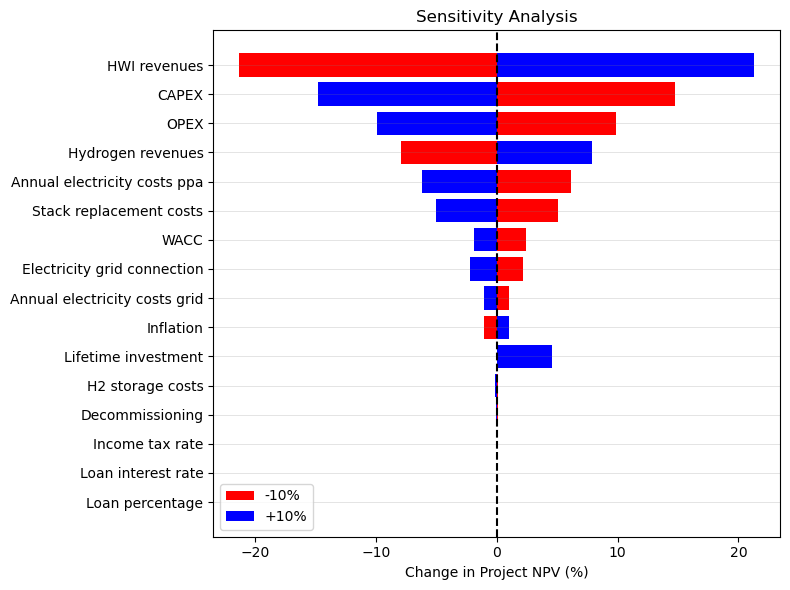

In [57]:
tornado_plot(df_sa_project_npv, project_npv_base_case, 'Project NPV')

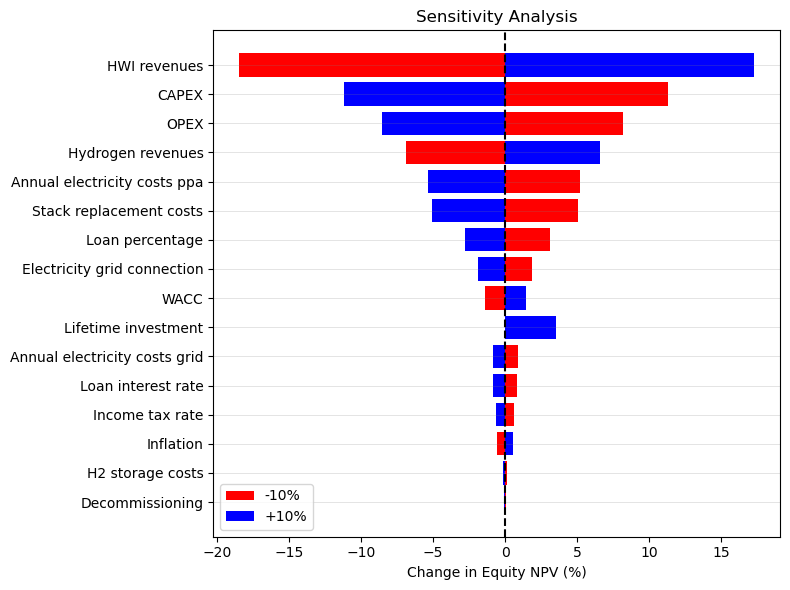

In [58]:
tornado_plot(df_sa_equity_npv,equity_npv_base_case, 'Equity NPV')

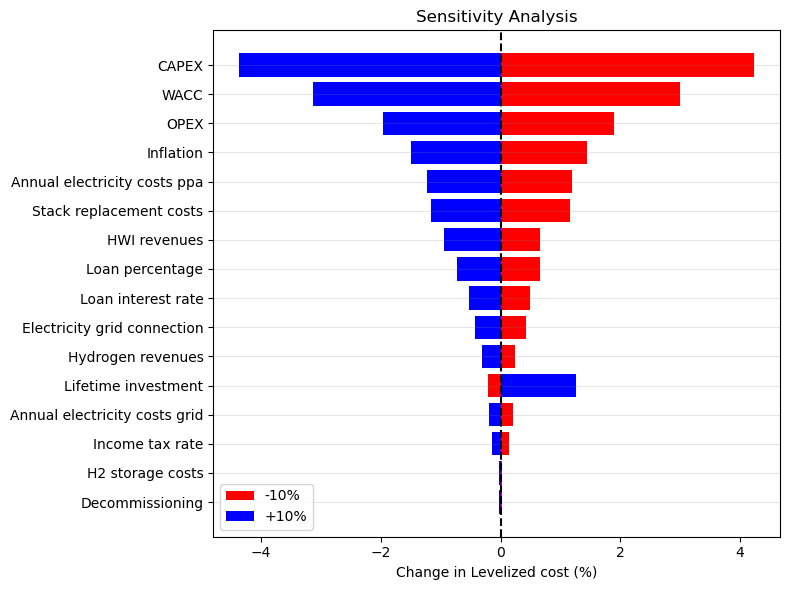

In [59]:
tornado_plot(df_sa_levelized_cost,levelized_cost_base_case, 'Levelized cost')

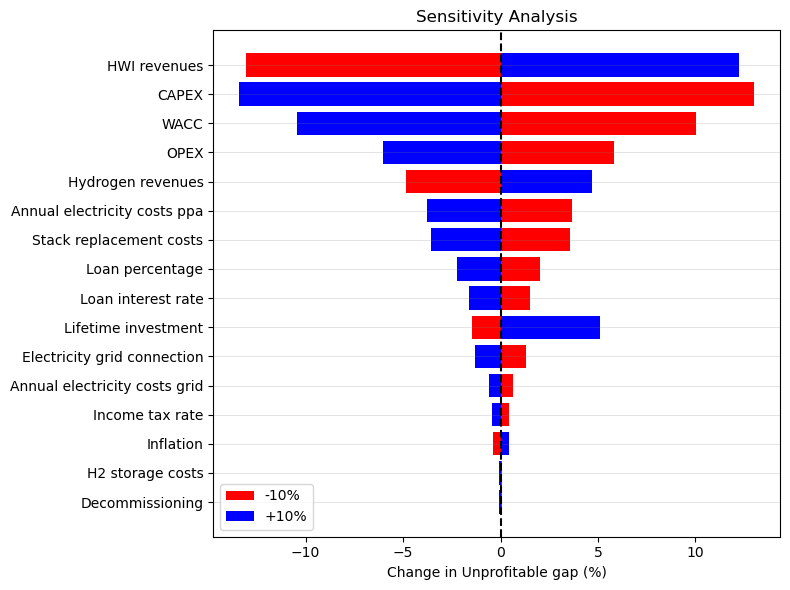

In [60]:
tornado_plot(df_sa_unprofitable_gap,unprofitable_gap_base_case, 'Unprofitable gap')

Cumulative equity and debt figure

In [61]:
df_cumulative_equity_and_debt_cashflows = cumulative_equity_and_debt_cashflows(el_capex_100mw,
                                                                               df_el_opex_100mw,
                                                                               el_inflation,
                                                                               el_annual_electricity_costs_ppa,
                                                                               el_annual_electricity_costs_grid,
                                                                               el_electricity_grid_connection,
                                                                               el_h2_storage_costs,
                                                                               df_stack_replacement_100mw,
                                                                               el_h2_revenues,
                                                                               el_hwi_revenues,
                                                                               el_decommissioning_percentage,
                                                                               el_loan_percentage,
                                                                               el_loan_interest_rate,
                                                                               el_income_tax_rate,
                                                                               el_lifetime)

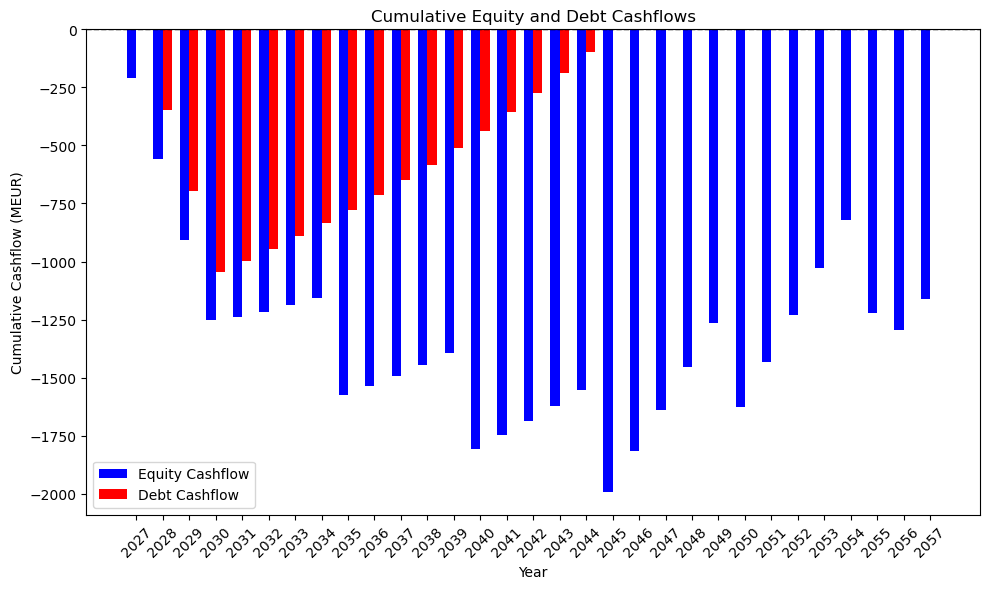

In [62]:
# Years from 2027 to 2057
years = construct_calendar_year_list(el_lifetime)  

cumulative_equity_cashflow = df_cumulative_equity_and_debt_cashflows.loc['cumulative_equity_cashflow'].tolist()

cumulative_debt_cashflow = df_cumulative_equity_and_debt_cashflows.loc['cumulative_debt_cashflow'].tolist()

# Set the width of each bar
bar_width = 0.35

# Set the position of the bars on the x-axis
r1 = np.arange(len(years))
r2 = [x + bar_width for x in r1]

# Create the plot
fig, ax = plt.subplots(figsize=(10, 6))

# Create bars for cumulative equity cashflow
ax.bar(r1, cumulative_equity_cashflow, color='blue', width=bar_width, label='Equity Cashflow')

# Create bars for cumulative debt cashflow
ax.bar(r2, cumulative_debt_cashflow, color='red', width=bar_width, label='Debt Cashflow')

# Add a horizontal line at y=0
ax.axhline(y=0, color='black', linestyle='--', linewidth=1)

# Add labels and title
ax.set_xlabel('Year')
ax.set_ylabel('Cumulative Cashflow (MEUR)')
ax.set_title('Cumulative Equity and Debt Cashflows')

# Add xticks on the middle of the group bars
ax.set_xticks([r + bar_width/2 for r in range(len(years))])
ax.set_xticklabels(years, rotation=45)

# Add legend
ax.legend()

# Display the plot
plt.tight_layout()
plt.show()
